# Optimización walk-forward focalizada del PEMS-PINN de NOX — R3_POC_EFFICIENT

**Versión:** `NOX_WF_OPT_R3_POC_EFFICIENT`  
**Estado:** notebook OPT reproducible; `SMOKE` no congela resultados y `FULL_AUTO`
produce handoff únicamente después de confirmación y ablación completas.  
**Propósito:** seleccionar una configuración PINN para NOX usando exclusivamente
`WF01`–`WF03` y mantener 2015 completamente cerrado.  
**Entorno previsto:** Google Colab con GPU; ejecución lineal mediante **Run all**.  
**Entrada canónica:** los folds y hashes de desarrollo de
`00_PEMS_PINN_WF_PROTOCOL - R1.ipynb`.  
**Salida canónica:** `models/wf/work_pinn_nox_wf_opt_r3_poc_efficient/`.

## Contrato científico R3

- `WF01`: 2011 → 2012; `WF02`: 2011–2012 → 2013; `WF03`: 2011–2013 → 2014.
- `WF04` y todo valor de 2015 pertenecen exclusivamente al notebook FINAL.
- `gap_records=0` y `temporal_weighting="uniform"` permanecen fijos.
- Física fija: `TIT_INC` sobre `TIT`; `lambda_phys` sí se optimiza.
- Scalers, cuantiles físicos, kNN y sintéticos se ajustan solo con TRAIN de cada fold.
- El score Optuna es predictivo; la física actúa como regularización y gate A/B/C.
- Los tres folds se evalúan completos por trial. Se paralelizan únicamente si un
  preflight demuestra equivalencia, memoria segura y aceleración real.
- Optuna usa `n_jobs=1`; nunca hay dos trials simultáneos compitiendo por la GPU.

## Campaña simplificada local

El protocolo WF R1 conserva una política de campaña histórica. R3 consume de ese
protocolo únicamente el diseño temporal, los hashes, `gap`, ponderación y contrato
físico. La campaña R3 es una decisión versionada de este OPT: cuatro anchors,
30 trials Optuna iniciales, bloques de cinco y máximo 55 intentos terminales;
Top‑3 × 3 semillas, Top‑2 × 5 semillas y ablación pareada sobre tres folds.

## Fuentes metodológicas

- protocolo WF R1 para cronología y barrera de 2015;
- OPT/FINAL interpolativos vigentes para búsqueda focalizada, recuperación SQLite,
  concurrencia segura, confirmación escalonada y evaluación final multisemilla;
- notebooks históricos R7/R9 para anchors y física por contaminante;
- Manual R4 y estructura canónica de Colab para legibilidad y rutas.

La validación es prospectiva anual dentro del periodo histórico. No constituye
certificación regulatoria, RATA ni demostración causal.


## Mapa del notebook

| Sección | Finalidad |
|---|---|
| `SEC-00` | propósito, linaje y navegación |
| `SEC-01` | entorno, dependencias y configuración |
| `SEC-02` | verificación FROZEN del protocolo R1 |
| `SEC-03` | materialización autorizada de DEV y folds |
| `SEC-04` | arquitectura, física, métricas y entrenamiento |
| `SEC-05` | pruebas mínimas e invariantes científicas |
| `SEC-06` | ejecución aislada y paralelización de folds |
| `SEC-07` | espacio de búsqueda y pruning escalonado |
| `SEC-08` | preflight, SQLite, Optuna y recuperación |
| `SEC-09` | ranking y parada adaptativa |
| `SEC-10` | confirmación, ablación y congelamiento |
| `SEC-11` | visualización, persistencia y manifiestos |
| `SEC-12` | ejecución principal, resumen y handoff |

La secuencia es lineal. Las referencias utilizadas para diseñar el método son
contexto de BUILD-TIME y no constituyen dependencias de RUNTIME.


## SEC-01 — Entorno, dependencias y configuración

Prepara Colab, centraliza las decisiones R3 y deriva todas las rutas desde una única raíz canónica.


### C-01.01 — Bootstrap de Colab

**Objetivo:** montar Drive e instalar únicamente dependencias ausentes  
**Entradas:** PROJECT_ROOT_PATH y RUN_MODE.  
**Salidas:** entorno listo para importar.  
**Control o detención:** ruta inválida o instalación fallida detiene la ejecución.


In [1]:
# [C-01.01] Bootstrap de Colab
# Ruta única del proyecto en Google Drive. Edite solo esta línea si su carpeta cambia.
PROJECT_ROOT_PATH = "C:\\ChatGPT-Work\\Walk_Forward R8"

# Use SMOKE para validar el entorno; cambie a FULL_AUTO para la campaña completa.
RUN_MODE = "FULL_AUTO"

import importlib.util
import subprocess
import sys

required_packages = []
if importlib.util.find_spec("optuna") is None:
    required_packages.append("optuna>=4,<5")
if importlib.util.find_spec("joblib") is None:
    required_packages.append("joblib>=1.3,<2")
if required_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *required_packages]
    )


### C-01.02 — Imports reproducibles

**Objetivo:** importar biblioteca estándar y dependencias científicas  
**Entradas:** entorno Python.  
**Salidas:** símbolos utilizados por el notebook.  
**Control o detención:** un import ausente produce un error explícito.


In [2]:
# [C-01.02] Imports reproducibles
import contextlib
import copy
import gc
import hashlib
import importlib.util
import io
import json
import math
import os
import platform
import random
import shutil
import sqlite3
import threading
import time
import uuid
import warnings
from dataclasses import asdict, dataclass, replace
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import psutil
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from joblib import Parallel, delayed, parallel_config
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


<USER_HOME>\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### C-01.03 / CFG-01–03 — Configuración central R3

**Objetivo:** congelar presupuesto, parada, confirmación y parámetros fijos antes de
ejecutar. **Salidas:** una única fuente de verdad para toda la campaña R3.


In [3]:
# [C-01.03] Configuración central R3
VERSION = "NOX_WF_OPT_R3_POC_EFFICIENT"
PROTOCOL_VERSION = "WF_PROTOCOL_R1"
RUN_MODE = RUN_MODE.upper()
if RUN_MODE not in {"SMOKE", "FULL_AUTO"}:
    raise ValueError("RUN_MODE debe ser SMOKE o FULL_AUTO")

FEATURES = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "TEY", "CDP"]
DEVELOPMENT_YEARS = [2011, 2012, 2013, 2014]
FINAL_TEST_YEAR = 2015
DEVELOPMENT_FOLD_NAMES = ["WF01", "WF02", "WF03"]
TARGET = "NOX"
PHYSICS_MODE = "TIT_INC"
PHYSICS_FEATURE = "TIT"
PHYSICS_SCALE_QUANTILES = (0.05, 0.95)
SEARCH_SEED = 42
OPTUNA_SEED = 20260817

# CFG-01 — Presupuesto y parada POC predefinidos antes de ejecutar.
ANCHORS_FULL_EVAL = 4
INITIAL_OPTUNA_TRIALS = 30
INITIAL_TRIALS = ANCHORS_FULL_EVAL + INITIAL_OPTUNA_TRIALS
STOP_POLICY_VERSION = "POC_EFFICIENT_STOP_POLICY_V3"
HARD_CAP_FALLBACK_MODE = "HIERARCHICAL_TOP3_MANDATORY_CONFIRMATION"
HARD_CAP_FALLBACK_MIN_ADMISSIBLE = 3
MIN_ATTEMPTED_TRIALS = 30
MIN_COMPLETE_DEVELOPMENT_TRIALS = 12
MIN_COMPLETE_OPTUNA_TRIALS = 8
MIN_COMPETITIVE_TRIALS = 3
ADAPTIVE_BLOCK_SIZE = 5
ADAPTIVE_PATIENCE_BLOCKS = 2
MIN_OBJECTIVE_IMPROVEMENT = 0.002
COMPETITIVE_BAND_DELTA = 0.010
ELITE_BAND_DELTA = 0.003
ELITE_BAND_MAX_MEMBERS = 5
MAX_TOTAL_DEVELOPMENT_TRIALS = 55
PARTIAL_TEMPORAL_SCREENING = False

# CFG-02 — Confirmación escalonada concentrada en candidatos informativos.
TOP_N_CONFIRMATION = 3
TOP_N_FINALISTS = 2
CONFIRMATION_SCREENING_SEEDS = [21, 42, 84]
CONFIRMATION_EXTENSION_SEEDS = [126, 168]
CONFIRMATION_FINAL_SEEDS = (
    CONFIRMATION_SCREENING_SEEDS + CONFIRMATION_EXTENSION_SEEDS
)
ABLATION_SEEDS = [21, 42, 84]
FINAL_SEEDS = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210]

# CFG-03 — Entrenamiento y controles científicos fijados por R3.
DEV_MAX_EPOCHS = 300
MAX_TRAINABLE_PARAMETERS = 350_000
EARLY_STOPPING_MIN_EPOCHS = 75
EARLY_STOPPING_PATIENCE_EVALS = 12
VALIDATION_EVERY_EPOCHS = 5
EARLY_STOPPING_MIN_DELTA = 1e-4
DELTA_TIT_REF_C = 100.0
DELTA_NOX_REF_MGM3 = 100.0
EPS_DIMENSIONLESS = 1e-6
PHYSICS_EVAL_ROWS = 2048
EXPECTED_PROTOCOL_KNN_K = 20
EXPECTED_PROTOCOL_KNN_QUANTILE = 0.99

FIXED_SEARCH_PARAMETERS = {
    "physics_mode": PHYSICS_MODE,
    "fourier_dim": 0,
    "fourier_scale": 0.05,
    "nonnegative_output": False,
    "physics_dropout_mode": "data_only_dropout",
    "max_epochs": DEV_MAX_EPOCHS,
    "gradient_clip": 5.0,
    "lr_scheduler": "cosine",
    "physics_penalty": "softplus",
    "tau_softplus": 0.05,
    "physics_warmup_fraction": 0.1,
    "physics_real_fraction": 0.25,
    "synthetic_levels": 5,
    "synthetic_batch_size": 256,
    "synthetic_local_span_std": 0.5,
}
FIXED_PARAMETER_SOURCE = "FROZEN_R3_SIMPLIFIED_CAMPAIGN"

CAMPAIGN_SCHEMA_VERSION = (
    "R3_ALL_THREE_WF_FOLDS_STOP_V3_TIT_INC_FIXED_EPOCHS"
)
NUM_WORKERS = 0
TF32 = True

# El TPE permanece secuencial; ningún worker de entrenamiento accede a Optuna.
OPTUNA_N_JOBS = 1
PARALLEL_STRATEGY = "FOLD_LEVEL_LOKY_PROCESSES"
FOLD_EXECUTION_POLICY = "ALL_THREE_WF_FOLDS_FULL_EVAL"
MAX_FOLD_WORKERS = 3
PARALLEL_CANDIDATE_WORKERS = (1, 2, 3)
PARALLEL_INNER_THREADS = 1
PARALLEL_MIN_SPEEDUP = 1.05
PARALLEL_GPU_MEMORY_FRACTION = 0.80
PREFLIGHT_FOLDS = 3
PREFLIGHT_MAX_EPOCHS = 5
PREFLIGHT_PROFILE_VERSION = "R3_TIT_INC_ALL_THREE_FOLDS_PREFLIGHT_V1"

LEGACY_R2_VERSION = "NOX_WF_OPT_R2_POC_EFFICIENT"
LEGACY_R2_NOTEBOOK_NAME = (
    "04_Gold_Standard_PINN_NOX_WF_OPT - R2_POC_EFFICIENT.ipynb"
)
LEGACY_R2_NOTEBOOK_SHA256 = (
    "b7ecebdfa6586ab101d73480d59b08b48a2b671f2fe6d4fb0c1af1ac98784cbe"
)
LEGACY_R2_OUTPUT_REL = (
    Path("models") / "wf" / "work_pinn_nox_wf_opt_r2_poc_efficient"
)
LEGACY_R2_STOP_POLICY_VERSION = "POC_EFFICIENT_STOP_POLICY_V2"
LEGACY_R2_CAMPAIGN_SCHEMA = (
    "R2_ALL_THREE_WF_FOLDS_STOP_V2_TIT_INC_FIXED_EPOCHS"
)
LEGACY_R2_EXPECTED_TRIALS = 55

CURRENT_NOTEBOOK_NAME = (
    "04_Gold_Standard_PINN_NOX_WF_OPT - R3_POC_EFFICIENT.ipynb"
)
UPSTREAM_NOTEBOOK_NAME = "00_PEMS_PINN_WF_PROTOCOL - R1.ipynb"
DOWNSTREAM_NOTEBOOK_NAME = (
    "04_Gold_Standard_PINN_NOX_WF_FINAL - R3F_STD.ipynb"
)
RAW_DATA_REL = Path("data") / "raw"
NOTEBOOKS_REL = Path("notebooks")
PROTOCOL_REL = Path("models") / "wf" / "work_pinn_wf_protocol"
OUTPUT_REL = (
    Path("models")
    / "wf"
    / "work_pinn_nox_wf_opt_r3_poc_efficient"
)


### C-01.04 — Trazabilidad criptográfica

**Objetivo:** normalizar contenido y calcular hashes reproducibles  
**Entradas:** objetos, bytes y archivos.  
**Salidas:** JSON canónico y SHA-256.  
**Control o detención:** archivos ilegibles generan excepción.


In [4]:
# [C-01.04] Trazabilidad criptográfica
# Utilidades reproducibles de rutas, semillas y persistencia.


def utc_now():
    return datetime.now(timezone.utc).isoformat()


def canonical_json(value):
    return json.dumps(
        value, ensure_ascii=False, sort_keys=True, separators=(",", ":"), default=str
    )


def sha256_bytes(value):
    return hashlib.sha256(value).hexdigest()


def sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def config_hash(cfg):
    return sha256_bytes(
        canonical_json({k: v for k, v in cfg.items() if k != "config_hash"}).encode("utf-8")
    )


### C-01.05 — Escritura atómica

**Objetivo:** evitar artefactos parciales durante interrupciones  
**Entradas:** rutas y contenido serializable.  
**Salidas:** JSON, CSV y texto persistidos.  
**Control o detención:** un reemplazo o escritura fallida no se oculta.


In [5]:
# [C-01.05] Escritura atómica
def atomic_text(path, text):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(text, encoding="utf-8")
    os.replace(tmp, path)


def atomic_json(path, value):
    atomic_text(path, json.dumps(value, ensure_ascii=False, indent=2, default=str) + "\n")


def atomic_csv(path, frame):
    atomic_text(path, frame.to_csv(index=False, lineterminator="\n"))


### C-01.06 — Semillas y determinismo práctico

**Objetivo:** aplicar semillas coherentes en Python, NumPy y PyTorch  
**Entradas:** semilla entera.  
**Salidas:** generadores configurados.  
**Control o detención:** GPU y concurrencia pueden conservar variación dentro de tolerancias.


In [6]:
# [C-01.06] Semillas y determinismo práctico
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass


### C-01.07 — Raíz canónica del proyecto

**Objetivo:** validar la estructura de Drive sin búsquedas recursivas  
**Entradas:** PROJECT_ROOT_PATH.  
**Salidas:** Path absoluto validado.  
**Control o detención:** un archivo o directorio obligatorio ausente detiene el notebook.


In [7]:
# [C-01.07] Raíz canónica del proyecto
def validate_project_root(project_root_path: str) -> Path:
    """Monta Drive y valida DEV/protocolo sin exigir la presencia física de TEST.

    La función no busca carpetas alternativas ni consulta variables de entorno. Esto
    evita que una ejecución use accidentalmente otra copia del proyecto.
    """
    if importlib.util.find_spec("google.colab") is not None:
        from google.colab import drive

        drive.mount("/content/drive", force_remount=False)

    root = Path(project_root_path).expanduser()
    if not root.is_absolute():
        raise ValueError("PROJECT_ROOT_PATH debe ser una ruta absoluta")
    root = root.resolve()

    required = [
        root / RAW_DATA_REL / f"gt_{year}.csv"
        for year in DEVELOPMENT_YEARS
    ]
    required.extend([root / NOTEBOOKS_REL, root / PROTOCOL_REL])
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "PROJECT_ROOT_PATH no contiene la estructura canónica requerida: "
            f"{missing}"
        )
    return root


### C-01.08 — Contrato de carpetas de salida

**Objetivo:** crear solo la carpeta R3 y sus subdirectorios  
**Entradas:** raíz validada y OUTPUT_REL.  
**Salidas:** CampaignPaths.  
**Control o detención:** no escribe fuera de work_pinn_nox_wf_opt_r3_poc_efficient.


In [8]:
# [C-01.08] Contrato de carpetas de salida
@dataclass
class CampaignPaths:
    root: Path
    work: Path
    audit: Path
    configs: Path
    optuna_development: Path
    optuna_smoke: Path
    tables: Path
    reports: Path


def make_paths(root: Path) -> CampaignPaths:
    work = root / OUTPUT_REL
    paths = CampaignPaths(
        root=root,
        work=work,
        audit=work / "audit",
        configs=work / "configs",
        optuna_development=work / "optuna" / "development",
        optuna_smoke=work / "optuna" / "smoke",
        tables=work / "tables",
        reports=work / "reports",
    )
    for value in asdict(paths).values():
        Path(value).mkdir(parents=True, exist_ok=True)

    return paths


### C-01.09 — Manifiesto del entorno

**Objetivo:** registrar versiones y recursos que afectan reproducibilidad  
**Entradas:** dispositivo y configuración paralela.  
**Salidas:** diccionario del entorno.  
**Control o detención:** no afirma determinismo bit a bit.


In [9]:
# [C-01.09] Manifiesto del entorno
def environment_manifest(device):
    gpu_total_memory_gb = None
    if torch.cuda.is_available():
        gpu_total_memory_gb = torch.cuda.get_device_properties(0).total_memory / 2**30
    return {
        "generated_at_utc": utc_now(),
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
        "torch": torch.__version__,
        "optuna": optuna.__version__,
        "joblib": joblib.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "device": str(device),
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "gpu_total_memory_gb": gpu_total_memory_gb,
        "ram_gb": psutil.virtual_memory().total / 2**30,
        "tf32": TF32,
        "deterministic_warn_only": True,
        "parallel_strategy": PARALLEL_STRATEGY,
        "parallel_backend": "loky",
        "parallel_candidate_workers": list(PARALLEL_CANDIDATE_WORKERS),
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "max_fold_workers": MAX_FOLD_WORKERS,
    }


## SEC-02 — Contrato FROZEN del protocolo R1

Autentica los artefactos producidos por PROTOCOL R1 y declara el linaje PROTOCOL → OPT → FINAL. No inspecciona código histórico.


### C-02.01 / ALG-01 — Verificación integral del protocolo

**Objetivo:** aceptar únicamente la interfaz FROZEN del protocolo R1  
**Entradas:** manifiestos, asignación y CSV autorizados por hash.  
**Salidas:** assignment, manifests y estado autenticado.  
**Control o detención:** versión, estado, esquema, folds, kNN o hashes distintos detienen la campaña.

**Lógica humana:**
1. comprobar existencia y estado FROZEN del manifiesto general y los tres manifiestos científicos
2. autenticar asignación, folds y dominio contra el manifiesto general
3. reconciliar esquema, tres folds, anclas y exclusión de TEST
4. autorizar solo los cuatro CSV DEV por hash; 2015 permanece sin leer ni hashear


In [10]:
# [C-02.01] Verificación integral del protocolo WF R1
def verify_protocol(
    root: Path,
    paths: CampaignPaths,
) -> tuple[pd.DataFrame, dict, dict]:
    """Autentica únicamente el contrato temporal de WF_PROTOCOL_R1.

    `WF_CAMPAIGN_POLICY.json` es legado de la generación R1 y no gobierna la
    campaña simplificada R3. Esta separación queda registrada en el linaje.
    """
    base = root / PROTOCOL_REL
    manifests_dir = base / "manifests"
    tables_dir = base / "tables"
    required = {
        "protocol": manifests_dir / "WF_PROTOCOL_MANIFEST.json",
        "folds": manifests_dir / "WF_FOLDS_MANIFEST.json",
        "consumers": manifests_dir / "WF_CONSUMER_CONTRACT.json",
        "general": manifests_dir / "MANIFIESTO_ARTEFACTOS_WF_PROTOCOL.json",
        "assignment": tables_dir / "WF_DEVELOPMENT_ROW_ASSIGNMENT.csv",
        "fold_summary": tables_dir / "WF_FOLDS_SUMMARY.csv",
    }
    missing = [str(path) for path in required.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Artefactos FROZEN WF ausentes: {missing}")

    manifests = {
        name: json.loads(path.read_text(encoding="utf-8"))
        for name, path in required.items()
        if name not in {"assignment", "fold_summary"}
    }
    for name in ("protocol", "folds", "consumers", "general"):
        if manifests[name].get("status") != "FROZEN":
            raise RuntimeError(f"El manifiesto {name} no está FROZEN")
        if manifests[name].get("protocol_version") != PROTOCOL_VERSION:
            raise RuntimeError(f"Versión inesperada en {name}")

    indexed = {
        str(item["path"]).replace("\\", "/"): item["sha256"]
        for item in manifests["general"].get("artifacts", [])
    }
    canonical = {
        "manifests/WF_PROTOCOL_MANIFEST.json": required["protocol"],
        "manifests/WF_FOLDS_MANIFEST.json": required["folds"],
        "manifests/WF_CONSUMER_CONTRACT.json": required["consumers"],
        "tables/WF_DEVELOPMENT_ROW_ASSIGNMENT.csv": required["assignment"],
        "tables/WF_FOLDS_SUMMARY.csv": required["fold_summary"],
    }
    for relative, path in canonical.items():
        if indexed.get(relative) != sha256_file(path):
            raise RuntimeError(f"El manifiesto general no autentica {relative}")

    protocol = manifests["protocol"]
    folds_manifest = manifests["folds"]
    consumer = manifests["consumers"]
    if protocol.get("development_years") != DEVELOPMENT_YEARS:
        raise RuntimeError("Años DEV incompatibles con R3")
    if int(protocol.get("final_test_year", -1)) != FINAL_TEST_YEAR:
        raise RuntimeError("Año TEST incompatible con R2")
    if protocol.get("features") != FEATURES:
        raise RuntimeError("Features incompatibles con R3")
    if protocol.get("fixed_parameters") != {
        "gap_records": 0,
        "temporal_weighting": "uniform",
    }:
        raise RuntimeError("Gap o ponderación temporal incompatibles")
    if folds_manifest.get("development_folds") != DEVELOPMENT_FOLD_NAMES:
        raise RuntimeError("Los folds de desarrollo no son WF01–WF03")
    if folds_manifest.get("final_fold") != "WF04":
        raise RuntimeError("WF04 no figura como fold FINAL")

    target_contract = consumer["target_contracts"][TARGET]
    if target_contract.get("physics_mode") != PHYSICS_MODE:
        raise RuntimeError("Modo físico distinto al contrato WF")
    if target_contract.get("physics_feature") != PHYSICS_FEATURE:
        raise RuntimeError("Variable física distinta al contrato WF")
    common = consumer["common_contract"]
    if common.get("opt_may_read_2015_features"):
        raise RuntimeError("El protocolo permite indebidamente X_2015 en OPT")
    if common.get("opt_may_read_2015_targets"):
        raise RuntimeError("El protocolo permite indebidamente y_2015 en OPT")

    assignment_hash = sha256_file(required["assignment"])
    fold_summary_hash = sha256_file(required["fold_summary"])
    if assignment_hash != protocol.get("row_assignment_sha256"):
        raise RuntimeError("Hash de asignación distinto al protocolo")
    if assignment_hash != folds_manifest.get("row_assignment_sha256"):
        raise RuntimeError("Hash de asignación distinto al manifiesto de folds")
    if fold_summary_hash != protocol.get("fold_summary_sha256"):
        raise RuntimeError("Hash del resumen de folds distinto al protocolo")
    if fold_summary_hash != folds_manifest.get("fold_summary_sha256"):
        raise RuntimeError("Hash del resumen de folds inconsistente")

    assignment = pd.read_csv(required["assignment"])
    required_columns = {
        "global_row_id",
        "year",
        "row_in_year",
        "global_position",
        "WF01_role",
        "WF02_role",
        "WF03_role",
        "WF04_role",
    }
    if not required_columns.issubset(assignment.columns):
        raise ValueError("La asignación WF no contiene el esquema requerido")
    if assignment.global_row_id.duplicated().any():
        raise RuntimeError("global_row_id no es único")
    if sorted(assignment.year.unique().tolist()) != DEVELOPMENT_YEARS:
        raise RuntimeError("La asignación materializa un año no autorizado")
    if FINAL_TEST_YEAR in assignment.year.unique():
        raise RuntimeError("2015 aparece materializado en la asignación DEV")

    expected_hashes = {
        int(item["year"]): item["sha256"]
        for item in protocol.get("development_data_hashes", [])
    }
    if set(expected_hashes) != set(DEVELOPMENT_YEARS):
        raise RuntimeError("El protocolo no declara cuatro hashes DEV")
    for year in DEVELOPMENT_YEARS:
        data_path = root / RAW_DATA_REL / f"gt_{year}.csv"
        if sha256_file(data_path) != expected_hashes[year]:
            raise RuntimeError(f"Hash inesperado para gt_{year}.csv")

    audit = pd.DataFrame(
        [
            {
                "artifact": name,
                "path": str(path.relative_to(root)).replace("\\", "/"),
                "sha256": sha256_file(path),
            }
            for name, path in required.items()
        ]
    )
    atomic_csv(paths.audit / "PROTOCOL_INPUT_HASHES_NOX_WF_R3.csv", audit)
    status = {
        "protocol": "FROZEN",
        "assignment_sha256": assignment_hash,
        "fold_assignment_sha256": fold_summary_hash,
        "knn_k": EXPECTED_PROTOCOL_KNN_K,
        "knn_quantile": EXPECTED_PROTOCOL_KNN_QUANTILE,
        "knn_policy": "FIT_ON_EACH_FOLD_TRAIN_ONLY",
        "protocol_campaign_policy": "LEGACY_R1_NOT_CONSUMED",
        "upstream_notebook": UPSTREAM_NOTEBOOK_NAME,
        "general_manifest_sha256": sha256_file(required["general"]),
    }
    return assignment, manifests, status


### C-02.02 — Inicialización y contrato de linaje

**Objetivo:** inicializar dispositivo, rutas y artefactos de auditoría  
**Entradas:** raíz, configuración y protocolo autenticado.  
**Salidas:** PATHS, DEVICE, PROTOCOL_STATUS y contrato de linaje.  
**Control o detención:** FULL_AUTO sin GPU se advierte; protocolo inválido ya fue rechazado.


In [11]:
# [C-02.02] Inicialización y contrato de linaje
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)
PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
PATHS = make_paths(PROJECT_ROOT)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = TF32
    torch.backends.cudnn.allow_tf32 = TF32
elif RUN_MODE == "FULL_AUTO":
    print("FULL_AUTO conserva el presupuesto definido; se recomienda una GPU en Colab.")

ENVIRONMENT = environment_manifest(DEVICE)
atomic_json(PATHS.audit / "ENVIRONMENT_NOX_WF_R3.json", ENVIRONMENT)
ASSIGNMENT, PROTOCOL_MANIFESTS, PROTOCOL_STATUS = verify_protocol(PROJECT_ROOT, PATHS)
KNN_K = PROTOCOL_STATUS["knn_k"]
KNN_QUANTILE = PROTOCOL_STATUS["knn_quantile"]

LINEAGE_CONTRACT = {
    "status": "PASS",
    "current_notebook": CURRENT_NOTEBOOK_NAME,
    "upstream_notebook": UPSTREAM_NOTEBOOK_NAME,
    "upstream_artifact_root": str(PROTOCOL_REL),
    "authorized_primary_data": str(RAW_DATA_REL),
    "primary_data_authorization": "hashes declared by protocol R1",
    "output_root": str(OUTPUT_REL),
    "authorized_direct_consumer": DOWNSTREAM_NOTEBOOK_NAME,
    "test_target_materialized": False,
}
atomic_json(
    PATHS.audit / "RUNTIME_LINEAGE_CONTRACT_NOX_WF_R3.json",
    LINEAGE_CONTRACT,
)

if RUN_MODE == "FULL_AUTO":
    print("=" * 80)
    print("ADVERTENCIA: RUN_MODE='FULL_AUTO'")
    print("Se ejecutará la campaña completa con tres folds WF y confirmación multisemilla.")
    print("La duración esperada es de muchas horas o días; use GPU en Colab.")
    print("Para una prueba breve cambie RUN_MODE a 'SMOKE'.")
    print("=" * 80)

display(
    pd.Series(
        {
            "modo": RUN_MODE,
            "dispositivo": str(DEVICE),
            "protocolo": PROTOCOL_STATUS["protocol"],
            "kNN fold-train-only": f"k={KNN_K}, q={KNN_QUANTILE}",
            "muestra física por fold": PHYSICS_EVAL_ROWS,
            "estrategia paralela": PARALLEL_STRATEGY,
            "workers candidatos": list(PARALLEL_CANDIDATE_WORKERS),
            "Optuna n_jobs": OPTUNA_N_JOBS,
            "raíz del proyecto": str(PROJECT_ROOT),
            "salidas": str(PATHS.work),
        },
        name="valor",
    ).to_frame()
)


ADVERTENCIA: RUN_MODE='FULL_AUTO'
Se ejecutará la campaña completa con tres folds WF y confirmación multisemilla.
La duración esperada es de muchas horas o días; use GPU en Colab.
Para una prueba breve cambie RUN_MODE a 'SMOKE'.


,valor
modo,FULL_AUTO
dispositivo,cuda
protocolo,FROZEN
kNN fold-train-only,"k=20, q=0.99"
muestra física por fold,2048
estrategia paralela,FOLD_LEVEL_LOKY_PROCESSES
workers candidatos,"[1, 2, 3]"
Optuna n_jobs,1
raíz del proyecto,C:\ChatGPT-Work\Walk_Forward R8
salidas,C:\ChatGPT-Work\Walk_Forward R8\models\wf\work...


## SEC-03 — Materialización autorizada de DEV

Carga únicamente las filas DEV indicadas por el protocolo. Los CSV son datos primarios autorizados por hash, no una dependencia de otro notebook.


### C-03.01 / ALG-02 — Carga assignment-first de DEV

**Objetivo:** materializar X y NOx solo para filas DEV  
**Entradas:** asignación FROZEN y CSV autenticados.  
**Salidas:** DEV_DATA y auditoría de acceso al objetivo.  
**Control o detención:** cualquier fila TEST materializada, NaN, Inf o esquema incompleto detiene.

**Lógica humana:**
1. seleccionar metadatos DEV antes de leer el objetivo
2. cargar variables operativas y NOx únicamente para índices autorizados
3. reconciliar conteos e identidad por año
4. registrar que TEST y el contaminante no objetivo permanecen cerrados


In [12]:
# [C-03.01] Carga protegida de desarrollo 2011–2014
def load_dev_authorized(root, assignment, paths):
    """Materializa X y el target solo para los cuatro años DEV autorizados."""
    frames = []
    events = []
    forbidden_target = "CO"
    expected_hashes = {
        int(item["year"]): item["sha256"]
        for item in PROTOCOL_MANIFESTS["protocol"]["development_data_hashes"]
    }
    for year in DEVELOPMENT_YEARS:
        metadata = assignment.loc[assignment.year.eq(year)].sort_values(
            "row_in_year"
        )
        csv_path = root / RAW_DATA_REL / f"gt_{year}.csv"
        if sha256_file(csv_path) != expected_hashes[year]:
            raise RuntimeError(f"Hash DEV alterado en {year}")
        header = pd.read_csv(csv_path, nrows=0).columns.tolist()
        if not set(FEATURES + [TARGET, forbidden_target]).issubset(header):
            raise ValueError(f"Columnas faltantes en {csv_path.name}")
        values = pd.read_csv(csv_path, usecols=FEATURES + [TARGET])[
            FEATURES + [TARGET]
        ]
        if len(values) != len(metadata):
            raise RuntimeError(f"Conteo no reconciliado en {year}")
        frame = metadata[
            ["global_row_id", "year", "row_in_year", "global_position"]
            + [f"{name}_role" for name in DEVELOPMENT_FOLD_NAMES]
        ].reset_index(drop=True)
        frame = pd.concat([frame, values.reset_index(drop=True)], axis=1)
        frames.append(frame)
        events.append(
            {
                "year": year,
                "rows_target_materialized": len(values),
                "non_target_pollutant_materialized": False,
                "operation": "FEATURES_PLUS_AUTHORIZED_TARGET",
            }
        )

    data = pd.concat(frames, ignore_index=True)
    if data.global_row_id.duplicated().any():
        raise RuntimeError("DEV contiene IDs duplicados")
    if sorted(data.year.unique().tolist()) != DEVELOPMENT_YEARS:
        raise RuntimeError("DEV contiene años no autorizados")
    if not np.isfinite(data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError("DEV contiene NaN o infinito")
    audit = {
        "status": "PASS",
        "target": TARGET,
        "development_years": DEVELOPMENT_YEARS,
        "dev_target_rows_materialized": len(data),
        "test_target_rows_materialized": 0,
        "test_feature_rows_materialized": 0,
        "test_content_sha256_computed": False,
        "non_target_pollutant_materialized": False,
        "events": events,
        "generated_at_utc": utc_now(),
    }
    atomic_json(paths.audit / "TARGET_ACCESS_AUDIT_NOX_WF_R3.json", audit)
    return data, audit


### C-03.02 — Reconstrucción de los tres folds

**Objetivo:** convertir la asignación FROZEN en índices train/validation  
**Entradas:** DEV_DATA y columnas cv_role/cv_fold.  
**Salidas:** FOLDS y tabla de tamaños.  
**Control o detención:** fold vacío, solapamiento o bloque dividido detiene.


In [13]:
# [C-03.02] Reconstrucción de WF01–WF03
def reconstruct_folds(data, assignment):
    """Reconstruye los tres folds expansivos desde las columnas FROZEN."""
    observed_ids = data["global_row_id"].astype(str).reset_index(drop=True)
    expected_ids = assignment["global_row_id"].astype(str).reset_index(drop=True)
    if not observed_ids.equals(expected_ids):
        raise RuntimeError("DEV y assignment no conservan el mismo orden de filas")
    folds = {}
    rows = []
    for fold_index, fold_name in enumerate(DEVELOPMENT_FOLD_NAMES):
        role_column = f"{fold_name}_role"
        train = np.flatnonzero(assignment[role_column].eq("TRAIN").to_numpy())
        validation = np.flatnonzero(
            assignment[role_column].eq("VALIDATION").to_numpy()
        )
        if not len(train) or not len(validation):
            raise RuntimeError(f"{fold_name} contiene una partición vacía")
        if np.intersect1d(train, validation).size:
            raise RuntimeError(f"{fold_name} contiene solapamiento")
        train_years = sorted(data.iloc[train].year.unique().astype(int).tolist())
        validation_years = sorted(
            data.iloc[validation].year.unique().astype(int).tolist()
        )
        if max(train_years) >= min(validation_years):
            raise RuntimeError(f"{fold_name} viola la cronología estricta")
        folds[fold_index] = (train, validation)
        rows.append(
            {
                "fold": fold_index,
                "fold_name": fold_name,
                "train_years": ",".join(map(str, train_years)),
                "validation_year": validation_years[0],
                "N_train": len(train),
                "N_validation": len(validation),
            }
        )
    if len(folds) != 3:
        raise RuntimeError("R3 requiere exactamente tres folds de desarrollo")
    return folds, pd.DataFrame(rows)


def fold_signature(frame):
    columns = ["global_row_id"] + [
        f"{name}_role" for name in DEVELOPMENT_FOLD_NAMES
    ]
    payload = frame[columns].sort_values("global_row_id")
    return sha256_bytes(
        payload.to_csv(index=False, lineterminator="\n").encode("utf-8")
    )


### C-03.03 — Ejecución y prueba de independencia

**Objetivo:** materializar DEV, reconstruir folds y comprobar independencia de metadatos ajenos  
**Entradas:** funciones anteriores.  
**Salidas:** DEV_DATA, FOLDS y FOLD_TABLE persistida.  
**Control o detención:** una firma alterada o acceso a TEST detiene.


In [14]:
# [C-03.03] Ejecución y prueba de independencia
print("Fase 1 · Reconstrucción de DEV y folds desde WF_PROTOCOL_R1")
DEV_DATA, TARGET_ACCESS_AUDIT = load_dev_authorized(
    PROJECT_ROOT,
    ASSIGNMENT,
    PATHS,
)
FOLDS, FOLD_TABLE = reconstruct_folds(DEV_DATA, ASSIGNMENT)
atomic_csv(PATHS.tables / "FOLD_RECONSTRUCTION_NOX_WF_R3.csv", FOLD_TABLE)

probe = ASSIGNMENT.copy()
probe["__unrelated_probe"] = np.arange(len(probe))
if fold_signature(ASSIGNMENT) != fold_signature(probe):
    raise RuntimeError("Un metadato ajeno alteró los folds")
if TARGET_ACCESS_AUDIT["test_target_rows_materialized"] != 0:
    raise RuntimeError("2015 fue materializado durante OPT")

display(FOLD_TABLE)
print(
    {
        "filas DEV": len(DEV_DATA),
        "folds": list(FOLD_TABLE.fold_name),
        "filas 2015 materializadas": 0,
        "objetivo no target materializado": False,
    }
)


Fase 1 · Reconstrucción de DEV y folds desde WF_PROTOCOL_R1


,fold,fold_name,train_years,validation_year,N_train,N_validation
0,0,WF01,2011,2012,7411,7628
1,1,WF02,"2011,2012",2013,15039,7152
2,2,WF03,"2011,2012,2013",2014,22191,7158


{'filas DEV': 29349, 'folds': ['WF01', 'WF02', 'WF03'], 'filas 2015 materializadas': 0, 'objetivo no target materializado': False}


## SEC-04 — Núcleo científico del PINN

Define arquitectura, transformación del objetivo, restricción TIT_INC, sintéticos train-only, métricas y entrenamiento por fold.


### C-04.01 — Arquitectura y objetivo

**Objetivo:** definir la MLP monotónica y transformaciones del objetivo  
**Entradas:** configuración candidata y semilla.  
**Salidas:** modelo y funciones de transformación.  
**Control o detención:** configuración de activación o transformación desconocida detiene.


In [15]:
# [C-04.01] Arquitectura y objetivo
# El modelo mantiene separadas la representación y la escala física del objetivo.


class MonotonicMLP(nn.Module):
    def __init__(self, input_dim, cfg, seed):
        super().__init__()
        set_seed(seed)
        self.cfg = copy.deepcopy(cfg)
        self.fourier_dim = int(cfg.get("fourier_dim", 0))
        if self.fourier_dim:
            g = torch.Generator().manual_seed(seed)
            self.register_buffer(
                "fourier_B",
                torch.randn(input_dim, self.fourier_dim, generator=g)
                * float(cfg["fourier_scale"]),
            )
            dim = 2 * self.fourier_dim
        else:
            dim = input_dim
        acts = {"tanh": nn.Tanh, "silu": nn.SiLU, "gelu": nn.GELU, "softplus": nn.Softplus}
        layers = []
        for width in cfg["hidden_widths"]:
            layers += [nn.Linear(dim, int(width)), acts[cfg["activation"]]()]
            if cfg.get("dropout", 0) > 0 and cfg.get("physics_dropout_mode") != "no_dropout":
                layers.append(nn.Dropout(float(cfg["dropout"])))
            dim = int(width)
        layers.append(nn.Linear(dim, 1))
        self.net = nn.Sequential(*layers)
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        if self.fourier_dim:
            p = 2 * math.pi * x @ self.fourier_B
            x = torch.cat([torch.sin(p), torch.cos(p)], 1)
        out = self.net(x).squeeze(-1)
        return (
            F.softplus(out) if self.cfg.get("nonnegative_output") == "softplus_output" else out
        )


@contextlib.contextmanager
def dropout_temporarily_disabled(model):
    states = [(m, m.training) for m in model.modules() if isinstance(m, nn.Dropout)]
    try:
        for m, _ in states:
            m.training = False
        yield
    finally:
        for m, state in states:
            m.training = state


def target_forward(y, transform):
    y = np.asarray(y, float)
    if transform == "log1p":
        if y.min() <= -1:
            raise ValueError("log1p requiere objetivo > -1")
        return np.log1p(y)
    return y.copy()


def target_inverse(y_std, scaler, transform):
    z = scaler.inverse_transform(np.asarray(y_std).reshape(-1, 1)).ravel()
    return np.expm1(z) if transform == "log1p" else z


def inverse_target_tensor(y_std, scaler, transform):
    mean = torch.as_tensor(float(scaler.mean_[0]), device=y_std.device, dtype=y_std.dtype)
    scale = torch.as_tensor(float(scaler.scale_[0]), device=y_std.device, dtype=y_std.dtype)
    z = y_std * scale + mean
    return torch.expm1(z) if transform == "log1p" else z


### C-04.02 — Gradientes y pérdida física

**Objetivo:** calcular derivadas físicas y penalizar violaciones TIT_INC  
**Entradas:** modelo, tensores escalados y configuración.  
**Salidas:** gradientes y physics_loss.  
**Control o detención:** derivadas no finitas propagan error.


In [16]:
# [C-04.02] Gradientes y pérdida física
# Las derivadas y el soporte se calculan en unidades compatibles.


def physical_gradients(
    model: nn.Module,
    x_std: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    transform: str,
    feature_index: int,
    create_graph: bool = False,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Calcula la derivada local del NOx respecto a una entrada física.

    Autograd entrega ∂NOx/∂z para la entrada estandarizada z. La regla de la cadena
    divide por la escala de la variable original para obtener ∂NOx/∂x. Finalmente,
    `dimensionless_gradient` expresa el cambio relativo usando 100 °C de TIT y
    100 mg/m³ de NOx como escalas de referencia.
    """
    x_with_grad = x_std.detach().clone().requires_grad_(True)
    nox_physical = inverse_target_tensor(
        model(x_with_grad),
        y_scaler,
        transform,
    )
    gradient_standardized = torch.autograd.grad(
        nox_physical.sum(),
        x_with_grad,
        create_graph=create_graph,
    )[0][:, feature_index]
    feature_scale = torch.as_tensor(
        float(x_scaler.scale_[feature_index]),
        device=x_with_grad.device,
        dtype=x_with_grad.dtype,
    )
    physical_gradient = gradient_standardized / feature_scale
    dimensionless_gradient = (
        DELTA_TIT_REF_C / DELTA_NOX_REF_MGM3
    ) * physical_gradient
    return physical_gradient, dimensionless_gradient


def physics_loss(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
    feature_index: int,
) -> torch.Tensor:
    """Penaliza únicamente las derivadas que violan ∂NOx/∂TIT ≥ 0.

    `softplus` ofrece una aproximación suave a la bisagra negativa; la alternativa
    ReLU aplica una penalización cuadrática. El dropout puede desactivarse solo para
    esta evaluación física, según la configuración del trial.
    """
    dropout_context = (
        dropout_temporarily_disabled(model)
        if cfg["physics_dropout_mode"] == "data_only_dropout"
        else contextlib.nullcontext()
    )
    with dropout_context:
        _, dimensionless_gradient = physical_gradients(
            model,
            x,
            x_scaler,
            y_scaler,
            cfg["target_transform"],
            feature_index,
            create_graph=True,
        )
    if cfg["physics_penalty"] == "softplus":
        tau = float(cfg["tau_softplus"])
        return (tau * F.softplus(-dimensionless_gradient / tau)).mean()
    return F.relu(-dimensionless_gradient).square().mean()


_KNN_ENVELOPE_CACHE = {}


### C-04.03 — Soporte kNN y sintéticos train-only

**Objetivo:** construir soporte multivariable y puntos sintéticos desde fold-train  
**Entradas:** X_train y parámetros kNN del protocolo.  
**Salidas:** envolvente y puntos sintéticos intradominio.  
**Control o detención:** validation y TEST nunca ajustan soporte ni sintéticos.


In [17]:
# [C-04.03] Soporte kNN y sintéticos train-only
def fit_knn_envelope(x, k=KNN_K, q=KNN_QUANTILE):
    n = min(k + 1, len(x))
    model = NearestNeighbors(n_neighbors=n).fit(x)
    d, _ = model.kneighbors(x)
    kth = d[:, -1]
    return model, float(np.quantile(kth, q)), kth


def generate_synthetic_points(
    x_train: np.ndarray,
    scaler: StandardScaler,
    cfg: dict,
    seed: int,
) -> tuple[np.ndarray, dict]:
    """Perturba TIT localmente y conserva solo puntos dentro de la envolvente KNN.

    El vecino k-ésimo y su cuantil son política R3 y se calculan en el
    espacio estandarizado del entrenamiento del fold. Así, ningún punto sintético
    amplía el dominio observado.
    """
    if int(cfg.get("synthetic_base_rows", 0)) <= 0:
        return np.empty((0, x_train.shape[1]), np.float32), {
            "synthetic_attempted": 0,
            "synthetic_accepted": 0,
            "synthetic_acceptance_pct": 0.0,
        }
    rng = np.random.default_rng(seed)
    contiguous_train = np.ascontiguousarray(x_train, dtype=np.float32)
    cache_key = sha256_bytes(contiguous_train.view(np.uint8).tobytes())
    cached = _KNN_ENVELOPE_CACHE.get(cache_key)
    if cached is None:
        z = scaler.transform(contiguous_train)
        model, threshold, kth = fit_knn_envelope(z)
        cached = (z, model, threshold, kth)
        _KNN_ENVELOPE_CACHE[cache_key] = cached
    else:
        z, model, threshold, kth = cached
    n = min(int(cfg["synthetic_base_rows"]), len(z))
    idx = rng.choice(len(z), n, replace=False)
    levels = np.linspace(
        -float(cfg["synthetic_local_span_std"]),
        float(cfg["synthetic_local_span_std"]),
        int(cfg["synthetic_levels"]),
    )
    tit = FEATURES.index("TIT")
    cand = []
    for i in idx:
        for delta in levels:
            row = z[i].copy()
            row[tit] = np.clip(row[tit] + delta, z[:, tit].min(), z[:, tit].max())
            cand.append(row)
    cand = np.asarray(cand)
    d, _ = model.kneighbors(cand, n_neighbors=min(KNN_K, len(z)))
    accepted = cand[d[:, -1] <= threshold]
    if len(accepted):
        physical = scaler.inverse_transform(accepted)
    else:
        physical = np.empty((0, x_train.shape[1]))
    if (
        len(physical)
        and not (
            (physical >= x_train.min(0) - 1e-8) & (physical <= x_train.max(0) + 1e-8)
        ).all()
    ):
        raise AssertionError("Sintético fuera de soporte marginal")
    if not len(accepted):
        raise ValueError("synthetic_generation_empty")
    return accepted.astype(np.float32), {
        "synthetic_attempted": len(cand),
        "synthetic_accepted": len(accepted),
        "synthetic_acceptance_pct": 100 * len(accepted) / len(cand),
        "knn_threshold": threshold,
        "knn_k": KNN_K,
        "knn_quantile": KNN_QUANTILE,
        "train_kth_at_protocol_quantile": float(np.quantile(kth, KNN_QUANTILE)),
    }


### C-04.04 — Métricas predictivas y físicas

**Objetivo:** calcular métricas comparables y muestreo físico distribuido  
**Entradas:** observaciones, predicciones y modelo.  
**Salidas:** R², errores, sesgo, PCD y diagnósticos.  
**Control o detención:** muestras físicas se distribuyen determinísticamente en el fold.


In [18]:
# [C-04.04] Métricas predictivas y físicas
# Métricas predictivas, físicas y de complejidad del modelo.


def regression_metrics(y, p):
    y = np.asarray(y, float)
    p = np.asarray(p, float)
    e = p - y
    rmse = float(mean_squared_error(y, p) ** 0.5)
    span = float(np.ptp(y))
    sd = float(np.std(y, ddof=1))
    corr = float(np.corrcoef(y, p)[0, 1]) if np.std(y) and np.std(p) else np.nan
    slope, intercept = np.polyfit(y, p, 1)
    return {
        "R2": float(r2_score(y, p)),
        "RMSE": rmse,
        "MAE": float(mean_absolute_error(y, p)),
        "NRMSE_range": rmse / span if span else np.nan,
        "NRMSE_std": rmse / sd if sd else np.nan,
        "bias": float(e.mean()),
        "residual_std": float(e.std(ddof=1)),
        "pearson_r": corr,
        "slope": float(slope),
        "intercept": float(intercept),
        "negative_prediction_pct": float(100 * np.mean(p < 0)),
    }


def evenly_spaced_tensor_rows(
    values: torch.Tensor,
    max_rows: int = PHYSICS_EVAL_ROWS,
) -> torch.Tensor:
    """Selecciona posiciones deterministas distribuidas por todo el tensor."""
    if max_rows < 2:
        raise ValueError("max_rows debe ser al menos 2")
    if len(values) <= max_rows:
        return values
    indices = torch.linspace(
        0,
        len(values) - 1,
        steps=max_rows,
        device=values.device,
    ).round().long()
    return values.index_select(0, indices)


def monotonic_metrics(model, x, sx, sy, cfg, index):
    model.eval()
    grad, g = physical_gradients(model, x, sx, sy, cfg["target_transform"], index)
    a = grad.detach().cpu().numpy()
    b = g.detach().cpu().numpy()
    eps = EPS_DIMENSIONLESS
    return {
        "active_tit_pcd_pct": float(100 * np.mean(b >= -eps)),
        "active_tit_violation_pct": float(100 * np.mean(b < -eps)),
        "active_tit_near_zero_pct": float(100 * np.mean(np.abs(b) <= eps)),
        "dNOx_dTIT_phys_mean": float(a.mean()),
        "dNOx_dTIT_phys_median": float(np.median(a)),
        "dNOx_dTIT_phys_q05": float(np.quantile(a, 0.05)),
        "dNOx_dTIT_phys_q95": float(np.quantile(a, 0.95)),
        "g_star_mean": float(b.mean()),
        "g_star_median": float(np.median(b)),
        "g_star_q05": float(np.quantile(b, 0.05)),
        "g_star_q95": float(np.quantile(b, 0.95)),
    }


def diagnostic_cdp_metrics(model, x, sx, sy, cfg):
    model.eval()
    g, _ = physical_gradients(model, x, sx, sy, cfg["target_transform"], FEATURES.index("CDP"))
    a = g.detach().cpu().numpy()
    eps = EPS_DIMENSIONLESS
    return {
        "diagnostic_only_cdp_negative_gradient_pct": float(100 * np.mean(a < -eps)),
        "diagnostic_only_cdp_positive_gradient_pct": float(100 * np.mean(a > eps)),
        "diagnostic_only_cdp_near_zero_pct": float(100 * np.mean(np.abs(a) <= eps)),
        "diagnostic_only_dNOx_dCDP_median": float(np.median(a)),
    }


### C-04.05 — Complejidad y optimizador

**Objetivo:** contar parámetros y crear el optimizador declarado  
**Entradas:** modelo y configuración.  
**Salidas:** conteo y optimizador.  
**Control o detención:** optimizador desconocido detiene.


In [19]:
# [C-04.05] Complejidad y optimizador
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_optimizer(model, cfg):
    return {
        "AdamW": torch.optim.AdamW,
        "NAdam": torch.optim.NAdam,
        "RMSprop": torch.optim.RMSprop,
    }[cfg["optimizer"]](
        model.parameters(),
        lr=float(cfg["learning_rate"]),
        weight_decay=float(cfg["weight_decay"]),
    )


### C-04.06 / ALG-03 — Entrenamiento por fold

**Objetivo:** entrenar una configuración con preprocesamiento fold-train  
**Entradas:** train, validation, config, seed y device.  
**Salidas:** métricas, best_epoch e historial.  
**Control o detención:** early stopping, gradientes no finitos u OOM se gestionan explícitamente.

**Lógica humana:**
1. ajustar scalers y soporte solo con fold-train
2. entrenar pérdida de datos y física con warmup predefinido
3. evaluar validation periódicamente sin usar TEST
4. restaurar el mejor estado DEV y calcular métricas finales


In [20]:
# [C-04.06] Entrenamiento por fold
def train_fold(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    cfg: dict,
    seed: int,
    device: torch.device,
    smoke: bool = False,
) -> dict:
    """Entrena un fold sin ajustar transformaciones con datos de validación.

    Los escaladores, la envolvente KNN y los puntos sintéticos se ajustan solo con
    `x_train`/`y_train`. La validación decide el early stopping, pero nunca actualiza
    parámetros, escalas ni el soporte físico.
    """
    started = time.perf_counter()
    set_seed(seed)
    sx = StandardScaler().fit(x_train)
    transformed = target_forward(y_train, cfg["target_transform"])
    sy = StandardScaler().fit(transformed.reshape(-1, 1))
    xt = torch.from_numpy(sx.transform(x_train).astype(np.float32)).to(device)
    xv = torch.from_numpy(sx.transform(x_val).astype(np.float32)).to(device)
    physics_validation = evenly_spaced_tensor_rows(xv, PHYSICS_EVAL_ROWS)
    yt = torch.from_numpy(
        sy.transform(transformed.reshape(-1, 1)).ravel().astype(np.float32)
    ).to(device)
    synth_np, synth_stats = generate_synthetic_points(x_train, sx, cfg, seed)
    synth = torch.from_numpy(synth_np).to(device)
    model = MonotonicMLP(len(FEATURES), cfg, seed).to(device)
    if count_parameters(model) > MAX_TRAINABLE_PARAMETERS:
        raise ValueError("parameter_budget_exceeded")
    opt = make_optimizer(model, cfg)
    scheduler = None
    if cfg["lr_scheduler"] == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=int(cfg["max_epochs"])
        )
    elif cfg["lr_scheduler"] == "reduce_on_plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", patience=3)
    best_state = None
    best = None
    best_epoch = 0
    stale = 0
    history = []
    tit = FEATURES.index("TIT")
    batch = min(int(cfg["batch_size"]), len(xt))
    fixed_epochs = int(cfg.get("fixed_training_epochs", 0))
    every = (
        fixed_epochs
        if fixed_epochs
        else (1 if smoke else VALIDATION_EVERY_EPOCHS)
    )
    min_epochs = (
        fixed_epochs
        if fixed_epochs
        else (1 if smoke else EARLY_STOPPING_MIN_EPOCHS)
    )
    patience = (
        fixed_epochs + 1
        if fixed_epochs
        else (2 if smoke else EARLY_STOPPING_PATIENCE_EVALS)
    )
    for epoch in range(1, int(cfg["max_epochs"]) + 1):
        model.train()
        order = torch.randperm(len(xt), device=device)
        dsum = psum = nb = 0
        for pos in range(0, len(order), batch):
            ids = order[pos : pos + batch]
            xb, yb = xt[ids], yt[ids]
            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            err = (
                F.huber_loss(pred, yb, delta=float(cfg["huber_delta"]), reduction="mean")
                if cfg["loss_data"] == "huber"
                else F.mse_loss(pred, yb)
            )
            phys = []
            if float(cfg["lambda_phys"]) > 0:
                nreal = int(len(xb) * float(cfg["physics_real_fraction"]))
                if nreal:
                    phys.append(xb[:nreal])
                if len(synth):
                    ns = min(int(cfg["synthetic_batch_size"]), len(synth))
                    phys.append(synth[torch.randint(len(synth), (ns,), device=device)])
            if phys:
                p = physics_loss(model, torch.cat(phys), sx, sy, cfg, tit)
                warm = min(
                    1.0,
                    epoch
                    / max(1, int(cfg["max_epochs"] * float(cfg["physics_warmup_fraction"]))),
                )
            else:
                p = err.new_zeros(())
                warm = 0.0
            loss = err + float(cfg["lambda_phys"]) * warm * p
            if not torch.isfinite(loss):
                raise FloatingPointError("non_finite_loss")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), float(cfg["gradient_clip"]))
            opt.step()
            dsum += float(err.detach())
            psum += float(p.detach())
            nb += 1
        if scheduler is not None and cfg["lr_scheduler"] == "cosine":
            scheduler.step()
        if epoch == 1 or epoch % every == 0 or epoch == cfg["max_epochs"]:
            model.eval()
            with torch.no_grad():
                pv = target_inverse(model(xv).cpu().numpy(), sy, cfg["target_transform"])
            m = regression_metrics(y_val, pv)
            physm = monotonic_metrics(
                model,
                physics_validation,
                sx,
                sy,
                cfg,
                tit,
            )
            key = (m["R2"], -m["RMSE"], -physm["active_tit_violation_pct"], -epoch)
            history.append(
                {
                    "epoch": epoch,
                    "loss_data": dsum / max(1, nb),
                    "loss_physics": psum / max(1, nb),
                    **m,
                    **physm,
                }
            )
            improved = (
                epoch == fixed_epochs
                if fixed_epochs
                else (
                    best is None
                    or key[0] > best[0] + EARLY_STOPPING_MIN_DELTA
                    or (
                        abs(key[0] - best[0]) <= EARLY_STOPPING_MIN_DELTA
                        and key[1:] > best[1:]
                    )
                )
            )
            if improved:
                best = key
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch
                stale = 0
            else:
                stale += 1
            if scheduler is not None and cfg["lr_scheduler"] == "reduce_on_plateau":
                scheduler.step(m["R2"])
            if epoch >= min_epochs and stale >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pv = target_inverse(model(xv).cpu().numpy(), sy, cfg["target_transform"])
    metrics = regression_metrics(y_val, pv)
    metrics.update(
        monotonic_metrics(model, physics_validation, sx, sy, cfg, tit)
    )
    metrics.update(
        diagnostic_cdp_metrics(model, physics_validation, sx, sy, cfg)
    )
    metrics.update(
        best_epoch=best_epoch,
        parameter_count=count_parameters(model),
        training_time_s=time.perf_counter() - started,
        effective_batch_size=batch,
        physics_evaluation_rows=len(physics_validation),
        physics_evaluation_sampling="deterministic_evenly_spaced_full_fold",
        **synth_stats,
    )
    return {
        "model": model,
        "scaler_X": sx,
        "scaler_y": sy,
        "metrics": metrics,
        "history": history,
    }


## SEC-05 — Controles previos al experimento

Prueba invariantes del núcleo antes de consumir el presupuesto Optuna.


### C-05.01 — Configuración base de prueba

**Objetivo:** definir una configuración mínima reproducible  
**Entradas:** constantes R3.  
**Salidas:** BASE_CONFIG.  
**Control o detención:** no participa como resultado final.


In [21]:
# [C-05.01] Configuración base de prueba
BASE_CONFIG = {
    "name": "BASE",
    "hidden_widths": [64, 64],
    "activation": "tanh",
    "dropout": 0.03,
    "target_transform": "log1p",
    "loss_data": "mse",
    "huber_delta": 1.0,
    "optimizer": "NAdam",
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "batch_size": 512,
    "lambda_phys": 0.5,
    "synthetic_base_rows": 128,
    **FIXED_SEARCH_PARAMETERS,
    "config_source": "BASE_PREFLIGHT",
    "parameter_sources": {
        name: FIXED_PARAMETER_SOURCE for name in FIXED_SEARCH_PARAMETERS
    },
}


### C-05.02 — Pruebas del núcleo PINN

**Objetivo:** detectar fallos silenciosos de formas, gradientes, folds y protección TEST  
**Entradas:** DEV_DATA, FOLDS y DEVICE.  
**Salidas:** diccionario de checks.  
**Control o detención:** cualquier invariante fallida detiene antes de Optuna.


In [22]:
# [C-05.02] Pruebas del núcleo PINN
def unit_tests(data, folds, device):
    checks = []
    train, val = folds[0]
    x = data[FEATURES].to_numpy(np.float32)
    sx = StandardScaler().fit(x[train])
    before = sx.mean_.copy()
    altered = x[val].copy() + 99999
    _ = altered
    checks.append(("scaler_fold_train_only", np.allclose(before, sx.mean_)))

    sequence = torch.arange(10, device=device).reshape(-1, 1)
    distributed = evenly_spaced_tensor_rows(sequence, 4).flatten().cpu().tolist()
    checks.append(("physics_sample_full_fold", distributed == [0, 3, 6, 9]))

    checks.append(("knn_fold_train_policy", KNN_K == 20 and np.isclose(KNN_QUANTILE, 0.99)))

    class Linear(nn.Module):
        def __init__(self):
            super().__init__()
            self.s = nn.Parameter(torch.tensor(4.0))

        def forward(self, z):
            return self.s * z[:, 0]

    xs = StandardScaler()
    xs.mean_ = np.array([10.0])
    xs.scale_ = np.array([2.0])
    xs.var_ = xs.scale_**2
    xs.n_features_in_ = 1
    ys = StandardScaler()
    ys.mean_ = np.array([3.0])
    ys.scale_ = np.array([5.0])
    ys.var_ = ys.scale_**2
    ys.n_features_in_ = 1
    g, gs = physical_gradients(
        Linear().to(device), torch.tensor([[0.3], [0.7]], device=device), xs, ys, "original", 0
    )
    checks.append(
        (
            "gradient_units",
            bool(
                torch.allclose(g, torch.full_like(g, 10.0), atol=1e-5) and torch.allclose(gs, g)
            ),
        )
    )
    cfg = {**BASE_CONFIG, "hidden_widths": [16, 16], "dropout": 0.2}
    z = torch.randn(8, 9, device=device)
    m = (
        MonotonicMLP(9, {**cfg, "physics_dropout_mode": "data_only_dropout"}, 7)
        .to(device)
        .train()
    )
    with dropout_temporarily_disabled(m):
        a, b = m(z), m(z)
    checks.append(("dropout_physics_deterministic", bool(torch.allclose(a, b))))
    syn, stats = generate_synthetic_points(
        x[train],
        StandardScaler().fit(x[train]),
        {**cfg, "synthetic_base_rows": 16, "synthetic_levels": 3, "synthetic_batch_size": 16},
        7,
    )
    checks.append(
        (
            "synthetic_envelope",
            len(syn) > 0 and stats["synthetic_accepted"] <= stats["synthetic_attempted"],
        )
    )
    m1 = MonotonicMLP(9, cfg, 11).to(device).eval()
    m2 = MonotonicMLP(9, cfg, 11).to(device).eval()
    checks.append(("model_reproducible", bool(torch.allclose(m1(z), m2(z)))))
    buf = io.BytesIO()
    torch.save(m1.state_dict(), buf)
    buf.seek(0)
    m2.load_state_dict(torch.load(buf, map_location=device, weights_only=True))
    checks.append(("serialization", bool(torch.allclose(m1(z), m2(z)))))
    frame = pd.DataFrame(checks, columns=["check", "pass"])
    frame["status"] = np.where(frame["pass"], "PASS", "FAIL")
    if not frame["pass"].all():
        raise AssertionError(frame.loc[~frame["pass"]].to_dict("records"))
    return frame


### C-05.03 — Ejecución de pruebas mínimas

**Objetivo:** ejecutar y mostrar los controles previos  
**Entradas:** núcleo y configuración base.  
**Salidas:** UNIT_CHECKS.  
**Control o detención:** una excepción impide continuar.


In [23]:
# [C-05.03] Ejecución de pruebas mínimas
UNIT_CHECKS = unit_tests(DEV_DATA, FOLDS, DEVICE)
atomic_csv(PATHS.audit / "REPRODUCIBILITY_CHECKS_NOX_WF_R3.csv", UNIT_CHECKS)
display(UNIT_CHECKS)


,check,pass,status
0,scaler_fold_train_only,True,PASS
1,physics_sample_full_fold,True,PASS
2,knn_fold_train_policy,True,PASS
3,gradient_units,True,PASS
4,dropout_physics_deterministic,True,PASS
5,synthetic_envelope,True,PASS
6,model_reproducible,True,PASS
7,serialization,True,PASS


## SEC-06 — Motor parallel-safe de folds

Aísla entrenamientos independientes en procesos loky. Los workers comparten una GPU y nunca escriben en Optuna ni en Drive.


### C-06.01 — Contrato serializable de fold

**Objetivo:** encapsular datos, firmas, configuración y semilla por tarea  
**Entradas:** DEV, folds y configuración.  
**Salidas:** lista de FoldTask.  
**Control o detención:** las firmas preservan identidad de train y validation.


In [24]:
# [C-06.01] Contrato serializable de fold
@dataclass(frozen=True)
class FoldTask:
    """Contrato autocontenido para entrenar un fold en un proceso aislado."""

    fold: int
    seed: int
    train_signature: str
    validation_signature: str
    x_train: np.ndarray
    y_train: np.ndarray
    x_validation: np.ndarray
    y_validation: np.ndarray
    config: dict
    device_type: str
    smoke: bool = False


def array_index_signature(indices: np.ndarray) -> str:
    contiguous = np.ascontiguousarray(indices, dtype=np.int64)
    return sha256_bytes(contiguous.view(np.uint8).tobytes())


def build_fold_tasks(
    x: np.ndarray,
    y: np.ndarray,
    folds: dict,
    config: dict,
    seed: int,
    device: torch.device,
    fold_ids: list[int] | None = None,
    smoke: bool = False,
) -> list[FoldTask]:
    """Construye tareas en el orden canónico de los folds congelados."""
    selected = list(folds) if fold_ids is None else list(fold_ids)
    tasks = []
    for fold in selected:
        train_index, validation_index = folds[fold]
        tasks.append(
            FoldTask(
                fold=int(fold),
                seed=int(seed),
                train_signature=array_index_signature(train_index),
                validation_signature=array_index_signature(validation_index),
                x_train=np.ascontiguousarray(x[train_index], dtype=np.float32),
                y_train=np.ascontiguousarray(y[train_index], dtype=np.float32),
                x_validation=np.ascontiguousarray(
                    x[validation_index],
                    dtype=np.float32,
                ),
                y_validation=np.ascontiguousarray(
                    y[validation_index],
                    dtype=np.float32,
                ),
                config=copy.deepcopy(config),
                device_type=device.type,
                smoke=smoke,
            )
        )
    return tasks


### C-06.02 / ALG-04 — Runtime aislado del worker

**Objetivo:** configurar cada proceso y ejecutar un fold con telemetría  
**Entradas:** FoldTask.  
**Salidas:** resultado serializable con métricas y memoria.  
**Control o detención:** OOM y fallos se devuelven al maestro con estado explícito.

**Lógica humana:**
1. inicializar hilos, TF32, determinismo práctico y dispositivo
2. entrenar una única tarea sin rutas persistentes
3. sincronizar GPU y registrar memoria pico
4. liberar caché y comunicar COMPLETE, OOM o FAIL


In [25]:
# [C-06.02] Runtime aislado del worker
def configure_worker_runtime(device: torch.device) -> dict:
    """Replica en cada proceso la configuración numérica del proceso maestro."""
    torch.set_num_threads(PARALLEL_INNER_THREADS)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass
    torch.use_deterministic_algorithms(True, warn_only=True)

    if device.type == "cuda":
        torch.cuda.set_device(0)
        # Los procesos loky importan PyTorch de forma independiente y no heredan
        # estas banderas del kernel. La equivalencia exige configurarlas por worker.
        torch._C._set_cublas_allow_tf32(bool(TF32))
        torch._C._set_cudnn_allow_tf32(bool(TF32))
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)

    return {
        "device_type": device.type,
        "torch_version": torch.__version__,
        "cuda_version": torch.version.cuda,
        "tf32_matmul": (
            bool(torch._C._get_cublas_allow_tf32())
            if device.type == "cuda"
            else None
        ),
        "tf32_cudnn": (
            bool(torch._C._get_cudnn_allow_tf32())
            if device.type == "cuda"
            else None
        ),
        "deterministic_algorithms": torch.are_deterministic_algorithms_enabled(),
        "inner_threads": torch.get_num_threads(),
    }


def runtime_signature(runtime: dict) -> str:
    """Resume la política numérica efectiva para compararla entre procesos."""
    return config_hash(runtime)


def execute_fold_task(task: FoldTask) -> dict:
    """Entrena una tarea y retorna solo métricas serializables al maestro."""
    device = torch.device(task.device_type)
    worker_runtime = configure_worker_runtime(device)

    started = time.perf_counter()
    try:
        result = train_fold(
            task.x_train,
            task.y_train,
            task.x_validation,
            task.y_validation,
            task.config,
            task.seed,
            device,
            smoke=task.smoke,
        )
        if device.type == "cuda":
            torch.cuda.synchronize(device)
        metrics = copy.deepcopy(result["metrics"])
        peak_allocated = 0.0
        peak_reserved = 0.0
        if device.type == "cuda":
            peak_allocated = torch.cuda.max_memory_allocated(device) / 2**30
            peak_reserved = torch.cuda.max_memory_reserved(device) / 2**30
        del result
        return {
            "status": "COMPLETE",
            "fold": task.fold,
            "seed": task.seed,
            "N_train": len(task.x_train),
            "N_validation": len(task.x_validation),
            "train_signature": task.train_signature,
            "validation_signature": task.validation_signature,
            "worker_pid": os.getpid(),
            "worker_wall_time_s": time.perf_counter() - started,
            "worker_peak_gpu_allocated_gb": peak_allocated,
            "worker_peak_gpu_reserved_gb": peak_reserved,
            "worker_runtime_signature": runtime_signature(worker_runtime),
            "worker_tf32_matmul": worker_runtime["tf32_matmul"],
            "worker_tf32_cudnn": worker_runtime["tf32_cudnn"],
            "worker_deterministic_algorithms": worker_runtime[
                "deterministic_algorithms"
            ],
            "worker_inner_threads": worker_runtime["inner_threads"],
            **metrics,
        }
    except torch.cuda.OutOfMemoryError as exc:
        return {
            "status": "OOM",
            "fold": task.fold,
            "seed": task.seed,
            "error_type": type(exc).__name__,
            "error_message": str(exc),
        }
    except RuntimeError as exc:
        if device.type == "cuda" and "out of memory" in str(exc).lower():
            return {
                "status": "OOM",
                "fold": task.fold,
                "seed": task.seed,
                "error_type": type(exc).__name__,
                "error_message": str(exc),
            }
        return {
            "status": "FAIL",
            "fold": task.fold,
            "seed": task.seed,
            "error_type": type(exc).__name__,
            "error_message": str(exc),
        }
    except Exception as exc:
        return {
            "status": "FAIL",
            "fold": task.fold,
            "seed": task.seed,
            "error_type": type(exc).__name__,
            "error_message": str(exc),
        }
    finally:
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()


### C-06.03 — Orquestación loky

**Objetivo:** ejecutar tareas en orden y convertir fallos en excepciones del maestro  
**Entradas:** FoldTask y número de workers.  
**Salidas:** resultados ordenados.  
**Control o detención:** oversubscription se limita por workers e hilos internos.


In [26]:
# [C-06.03] Orquestación loky
def run_fold_tasks(tasks: list[FoldTask], workers: int) -> list[dict]:
    """Ejecuta folds con procesos loky y conserva el orden de entrada."""
    if not tasks:
        return []
    effective_workers = min(max(1, int(workers)), len(tasks))
    if effective_workers == 1:
        return [execute_fold_task(task) for task in tasks]

    # El caché del proceso maestro no debe viajar serializado a los workers.
    _KNN_ENVELOPE_CACHE.clear()
    with parallel_config(
        backend="loky",
        inner_max_num_threads=PARALLEL_INNER_THREADS,
    ):
        results = Parallel(
            n_jobs=effective_workers,
            batch_size=1,
            pre_dispatch=effective_workers,
            max_nbytes=None,
            mmap_mode=None,
            verbose=0,
        )(
            delayed(execute_fold_task)(task)
            for task in tasks
        )
    return results


def require_complete_fold(result: dict, context: str) -> dict:
    """Convierte estados de worker en fallos explícitos del proceso maestro."""
    if result["status"] == "COMPLETE":
        return result
    detail = (
        f"{context}; fold={result.get('fold')}; seed={result.get('seed')}; "
        f"{result.get('error_type')}: {result.get('error_message')}"
    )
    if result["status"] == "OOM":
        raise torch.cuda.OutOfMemoryError(detail)
    raise RuntimeError(detail)


## SEC-07 — Espacio focalizado y evaluación temporal completa

Cada anchor y cada trial se evalúan en `WF01`, `WF02` y `WF03`. No existe
screening temporal parcial ni promoción basada en los primeros años; Optuna
permanece secuencial (`n_jobs=1`) y los folds pueden ejecutarse en procesos
paralelos solo después del preflight de equivalencia y recursos.


### C-07.01 / CFG-04 — Anchors evaluados en tres folds

**Objetivo:** establecer una referencia competitiva antes de explorar.  
**Entradas:** una configuración histórica compatible y tres anchors compactos.  
**Salidas:** cuatro configuraciones con procedencia explícita.  
**Control:** ningún anchor puede podarse después de dos folds.


In [27]:
# [C-07.01] Cuatro candidatos ancla TIT_INC
def build_anchor(name: str, source: str, **overrides) -> dict:
    config = {**BASE_CONFIG, **overrides, "name": name}
    config.update(FIXED_SEARCH_PARAMETERS)
    config["config_source"] = source
    config["parameter_sources"] = {
        **BASE_CONFIG["parameter_sources"],
        **{key: source for key in overrides},
        **{key: FIXED_PARAMETER_SOURCE for key in FIXED_SEARCH_PARAMETERS},
    }
    return config


ANCHORS = [
    build_anchor(
        "ANCHOR_R7_TIT_INC_ADAPTED",
        "HISTORICAL_ANCHOR_R7_ADAPTED",
        hidden_widths=[192, 48, 192, 192, 96],
        activation="tanh",
        dropout=0.08,
        target_transform="log1p",
        loss_data="mse",
        optimizer="NAdam",
        learning_rate=0.0033089561690355313,
        batch_size=512,
        lambda_phys=4.0231308092338525,
        synthetic_base_rows=256,
    ),
    build_anchor(
        "ANCHOR_NOX_INTERP_R5_TRANSFER",
        "EXECUTED_INTERP_R5_CHAMPION_ADAPTED",
        hidden_widths=[64, 128],
        activation="silu",
        dropout=0.03,
        target_transform="original",
        loss_data="huber",
        huber_delta=0.3458550495,
        optimizer="AdamW",
        learning_rate=0.0025623203,
        weight_decay=1.905816e-6,
        batch_size=256,
        lambda_phys=3.9071959620,
        synthetic_base_rows=64,
    ),
    build_anchor(
        "ANCHOR_TIT_TANH_COMPACT",
        "MANUAL_COMPACT_ANCHOR",
        hidden_widths=[64, 64],
        activation="tanh",
    ),
    build_anchor(
        "ANCHOR_TIT_GELU_COMPACT",
        "MANUAL_COMPACT_ANCHOR",
        hidden_widths=[96, 96, 64],
        activation="gelu",
    ),
]
if len(ANCHORS) != ANCHORS_FULL_EVAL:
    raise RuntimeError("La cantidad de anchors no coincide con CFG-04")


### C-07.02 / CFG-05 — Espacio focalizado y objetivo robusto

**Objetivo:** concentrar el presupuesto en parámetros de alto impacto.  
**Entradas:** trial Optuna y decisiones fijas de `CFG-03`.  
**Salidas:** configuración completa con fuente por parámetro.  
**Control:** el score resume predicción; la física se aplica por gates separados.


In [28]:
# [C-07.02] Muestreo focalizado y objetivo predictivo robusto
def sample_trial_config(trial) -> dict:
    """Muestrea solo hiperparámetros de alto impacto para la POC R3."""
    hidden_layers = trial.suggest_int("n_hidden_layers", 2, 4)
    widths = [
        trial.suggest_categorical(
            f"width_{index}",
            [64, 96, 128, 160, 192],
        )
        for index in range(hidden_layers)
    ]
    data_loss = trial.suggest_categorical("loss_data", ["mse", "huber"])
    use_weight_decay = trial.suggest_categorical(
        "use_weight_decay",
        [False, True],
    )
    config = {
        **BASE_CONFIG,
        "name": f"TRIAL_{trial.number:04d}_TIT_INC",
        "hidden_widths": widths,
        "activation": trial.suggest_categorical(
            "activation",
            ["tanh", "silu", "gelu"],
        ),
        "dropout": trial.suggest_categorical(
            "dropout",
            [0.0, 0.03, 0.08, 0.15],
        ),
        "target_transform": trial.suggest_categorical(
            "target_transform",
            ["original", "log1p"],
        ),
        "loss_data": data_loss,
        "huber_delta": (
            trial.suggest_float("huber_delta", 0.25, 1.5)
            if data_loss == "huber"
            else 1.0
        ),
        "optimizer": trial.suggest_categorical(
            "optimizer",
            ["AdamW", "NAdam"],
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate",
            3e-4,
            6e-3,
            log=True,
        ),
        "weight_decay": (
            trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)
            if use_weight_decay
            else 0.0
        ),
        "batch_size": trial.suggest_categorical(
            "batch_size",
            [128, 256, 512],
        ),
        "lambda_phys": trial.suggest_float(
            "lambda_phys",
            1e-3,
            5.0,
            log=True,
        ),
        "synthetic_base_rows": trial.suggest_categorical(
            "synthetic_base_rows",
            [64, 128, 256],
        ),
        **FIXED_SEARCH_PARAMETERS,
        "config_source": "OPTUNA_FOCUSED_R3",
    }
    config["parameter_sources"] = {
        **{
            name: FIXED_PARAMETER_SOURCE
            for name in FIXED_SEARCH_PARAMETERS
        },
        **{
            name: "OPTUNA"
            for name in [
                "hidden_widths",
                "activation",
                "dropout",
                "target_transform",
                "loss_data",
                "huber_delta",
                "optimizer",
                "learning_rate",
                "weight_decay",
                "batch_size",
                "lambda_phys",
                "synthetic_base_rows",
            ]
        },
    }
    return config


def robust_score(metrics: list[dict]) -> float:
    """Resume robustez predictiva; la física se aplica como gate separado."""
    r2_values = np.array([metric["R2"] for metric in metrics])
    return float(
        0.60 * r2_values.min()
        + 0.30 * np.median(r2_values)
        + 0.10 * r2_values.mean()
        - 0.10 * r2_values.std()
    )


### C-07.03 / ALG-05 — Anchor-first con tres folds completos

**Lógica humana:**
1. evaluar los cuatro anchors en `WF01`–`WF03`;
2. evaluar cada trial Optuna en las tres fronteras temporales, sin filtro parcial;
3. mantener el objetivo exclusivamente predictivo;
4. registrar por separado el nivel físico A/B/C para admisibilidad y ranking;
5. podar únicamente por OOM, presupuesto paramétrico o error explícito, sin mutar
   la configuración ya hasheada.

Así, 2014 participa en todos los trials y no solo en candidatos promovidos.


In [29]:
# [C-07.03] Evaluación completa de los tres folds WF
def physics_level(metrics: list[dict]) -> str:
    pcd_minimum = min(metric["active_tit_pcd_pct"] for metric in metrics)
    if pcd_minimum >= 99:
        return "A"
    if pcd_minimum >= 95:
        return "B"
    return "C"


def best_anchor_screening_score(study) -> None:
    """Compatibilidad de interfaz: R3 no aplica screening parcial."""
    return None


def evaluate_config(
    data: pd.DataFrame,
    folds: dict,
    cfg: dict,
    seed: int,
    device: torch.device,
    trial=None,
    smoke: bool = False,
    is_anchor: bool = False,
    anchor_screening_score=None,
) -> list[dict]:
    """Evalúa WF01–WF03 completos; ningún fold futuro se usa como filtro previo."""
    del anchor_screening_score
    x = data[FEATURES].to_numpy(np.float32)
    y = data[TARGET].to_numpy(np.float32)
    trial_label = f"trial {trial.number}" if trial is not None else cfg["name"]
    tasks = build_fold_tasks(
        x,
        y,
        folds,
        cfg,
        seed,
        device,
        fold_ids=list(folds),
        smoke=smoke,
    )
    workers = min(PARALLEL_WORKERS, len(tasks))
    print(f"{trial_label} · WF01–WF03 completos · workers={workers}")
    started = time.perf_counter()
    results = run_fold_tasks(tasks, workers)
    rows = []
    for result in results:
        metrics = require_complete_fold(result, trial_label)
        rows.append(metrics)
        print(
            f"{trial_label} · {DEVELOPMENT_FOLD_NAMES[metrics['fold']]} · "
            f"R²={metrics['R2']:.4f}"
        )
    if len(rows) != len(folds):
        raise RuntimeError("La evaluación no cubrió los tres folds")
    if trial is not None:
        score = robust_score(rows)
        trial.report(score, step=len(rows))
        trial.set_user_attr("fold_metrics", copy.deepcopy(rows))
        trial.set_user_attr("decision", "COMPLETE_ALL_WF_FOLDS")
        trial.set_user_attr("promotion_status", "NOT_APPLICABLE_FULL_EVAL")
        trial.set_user_attr("is_anchor", bool(is_anchor))
    print(
        f"{trial_label} · evaluación completa · "
        f"{(time.perf_counter() - started) / 60:.1f} min"
    )
    return rows


## SEC-08 — Preflight, Optuna y recuperación

Valida equivalencia y memoria antes de paralelizar; mantiene Optuna secuencial con snapshots SQLite atómicos.


### C-08.01 — Configuración del preflight

**Objetivo:** preparar entorno y configuración fija  
**Entradas:** DEVICE y ANCHORS[0].  
**Salidas:** fingerprint y configuración.  
**Control o detención:** no consume presupuesto científico.


In [30]:
# [C-08.01] Configuración del preflight
PREFLIGHT_TOLERANCES = {
    "R2": {"atol": 1e-3, "rtol": 1e-4},
    "RMSE": {"atol": 1e-2, "rtol": 1e-4},
    "MAE": {"atol": 1e-2, "rtol": 1e-4},
    "active_tit_pcd_pct": {"atol": 0.10, "rtol": 0.0},
    "active_tit_violation_pct": {"atol": 0.10, "rtol": 0.0},
}


def parallel_environment_fingerprint() -> dict:
    return {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "joblib": joblib.__version__,
        "device_type": DEVICE.type,
        "tf32": TF32,
        "deterministic_warn_only": True,
        "parallel_inner_threads": PARALLEL_INNER_THREADS,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "max_fold_workers": MAX_FOLD_WORKERS,
        "gpu_name": (
            torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
        ),
        "gpu_total_memory_gb": (
            torch.cuda.get_device_properties(0).total_memory / 2**30
            if torch.cuda.is_available()
            else None
        ),
    }


def preflight_configuration() -> dict:
    """Aproxima el máximo uso de memoria sin consumir el presupuesto científico."""
    return {
        **ANCHORS[0],
        "name": "PARALLEL_PREFLIGHT_FIXED",
        "batch_size": 1024,
        "synthetic_batch_size": 512,
        "max_epochs": PREFLIGHT_MAX_EPOCHS,
    }


### C-08.02 — Comparación de equivalencia

**Objetivo:** comparar serial y paralelo dentro de tolerancias  
**Entradas:** resultados por fold.  
**Salidas:** tabla de equivalencia.  
**Control o detención:** diferencias fuera de tolerancia rechazan workers.


In [31]:
# [C-08.02] Comparación de equivalencia
def compare_preflight_results(
    reference: list[dict],
    candidate: list[dict],
    workers: int,
) -> pd.DataFrame:
    rows = []
    by_fold = {int(result["fold"]): result for result in candidate}
    for expected in reference:
        fold = int(expected["fold"])
        observed = by_fold[fold]
        exact_checks = {
            "train_signature": (
                expected["train_signature"] == observed["train_signature"]
            ),
            "validation_signature": (
                expected["validation_signature"]
                == observed["validation_signature"]
            ),
            "best_epoch": abs(
                int(expected["best_epoch"]) - int(observed["best_epoch"])
            ) <= VALIDATION_EVERY_EPOCHS,
            "parameter_count": (
                int(expected["parameter_count"])
                == int(observed["parameter_count"])
            ),
            "worker_runtime_signature": (
                expected["worker_runtime_signature"]
                == observed["worker_runtime_signature"]
            ),
        }
        for metric, passed in exact_checks.items():
            rows.append(
                {
                    "workers": workers,
                    "fold": fold,
                    "metric": metric,
                    "reference": expected[metric],
                    "candidate": observed[metric],
                    "absolute_difference": 0.0 if passed else np.nan,
                    "pass": bool(passed),
                }
            )
        for metric, tolerance in PREFLIGHT_TOLERANCES.items():
            passed = np.isclose(
                expected[metric],
                observed[metric],
                atol=tolerance["atol"],
                rtol=tolerance["rtol"],
            )
            rows.append(
                {
                    "workers": workers,
                    "fold": fold,
                    "metric": metric,
                    "reference": expected[metric],
                    "candidate": observed[metric],
                    "absolute_difference": abs(
                        expected[metric] - observed[metric]
                    ),
                    "pass": bool(passed),
                }
            )
    return pd.DataFrame(rows)


def valid_completed_results(results: list[dict]) -> bool:
    return bool(results) and all(row.get("status") == "COMPLETE" for row in results)


### C-08.03 / ALG-06 — Selección de concurrencia segura

**Objetivo:** medir tiempo, memoria y equivalencia  
**Entradas:** cinco FoldTask de preflight.  
**Salidas:** perfil paralelo.  
**Control o detención:** ningún paralelismo se habilita sin equivalencia y memoria.


In [32]:
# [C-08.03] Selección de concurrencia segura
def run_parallel_preflight() -> dict:
    """Selecciona concurrencia computacional sin observar TEST ni alterar Optuna."""
    profile_path = PATHS.audit / "PARALLEL_PROFILE_NOX_WF_R3.json"
    fingerprint = parallel_environment_fingerprint()
    if profile_path.is_file():
        saved = json.loads(profile_path.read_text(encoding="utf-8"))
        if (
            saved.get("status", "").startswith("PASS")
            and saved.get("profile_version") == PREFLIGHT_PROFILE_VERSION
            and saved.get("environment_fingerprint") == fingerprint
        ):
            saved["reused"] = True
            print(
                "Preflight parallel-safe restaurado: "
                f"workers={saved['selected_workers']}"
            )
            return saved

    config = preflight_configuration()
    x = DEV_DATA[FEATURES].to_numpy(np.float32)
    y = DEV_DATA[TARGET].to_numpy(np.float32)
    fold_ids = list(FOLDS)[:PREFLIGHT_FOLDS]
    tasks = build_fold_tasks(
        x,
        y,
        FOLDS,
        config,
        SEARCH_SEED,
        DEVICE,
        fold_ids=fold_ids,
        smoke=False,
    )

    print("Preflight parallel-safe · referencia serial")
    serial_started = time.perf_counter()
    serial_results = run_fold_tasks(tasks, 1)
    serial_elapsed = time.perf_counter() - serial_started
    if not valid_completed_results(serial_results):
        raise RuntimeError(f"Falló la referencia serial del preflight: {serial_results}")

    benchmark_rows = [
        {
            "workers": 1,
            "elapsed_s": serial_elapsed,
            "speedup": 1.0,
            "equivalence_pass": True,
            "memory_pass": True,
            "estimated_peak_reserved_gb": max(
                row["worker_peak_gpu_reserved_gb"] for row in serial_results
            ),
            "status": "REFERENCE",
        }
    ]
    equivalence_frames = []
    passing_parallel_workers = []
    numerical_mismatch_detected = False
    gpu_total = fingerprint["gpu_total_memory_gb"]

    for workers in PARALLEL_CANDIDATE_WORKERS:
        if workers == 1 or workers > len(tasks):
            continue
        print(f"Preflight parallel-safe · workers={workers}")
        # La primera ejecución inicializa procesos y contextos CUDA fuera del tiempo.
        warm_results = run_fold_tasks(tasks, workers)
        if not valid_completed_results(warm_results):
            benchmark_rows.append(
                {
                    "workers": workers,
                    "elapsed_s": np.nan,
                    "speedup": np.nan,
                    "equivalence_pass": False,
                    "memory_pass": False,
                    "estimated_peak_reserved_gb": np.nan,
                    "status": "WARMUP_FAILED",
                }
            )
            continue

        started = time.perf_counter()
        candidate_results = run_fold_tasks(tasks, workers)
        elapsed = time.perf_counter() - started
        if not valid_completed_results(candidate_results):
            benchmark_rows.append(
                {
                    "workers": workers,
                    "elapsed_s": elapsed,
                    "speedup": serial_elapsed / elapsed,
                    "equivalence_pass": False,
                    "memory_pass": False,
                    "estimated_peak_reserved_gb": np.nan,
                    "status": "EXECUTION_FAILED",
                }
            )
            continue

        comparison = compare_preflight_results(
            serial_results,
            candidate_results,
            workers,
        )
        equivalence_frames.append(comparison)
        equivalence_pass = bool(comparison["pass"].all())
        numerical_mismatch_detected |= not equivalence_pass
        reserved = sorted(
            [
                row["worker_peak_gpu_reserved_gb"]
                for row in candidate_results
            ],
            reverse=True,
        )
        estimated_peak = float(sum(reserved[:workers]))
        memory_pass = (
            True
            if gpu_total is None
            else estimated_peak <= PARALLEL_GPU_MEMORY_FRACTION * gpu_total
        )
        speedup = serial_elapsed / elapsed
        status = "PASS" if equivalence_pass and memory_pass else "REJECTED"
        benchmark_rows.append(
            {
                "workers": workers,
                "elapsed_s": elapsed,
                "speedup": speedup,
                "equivalence_pass": equivalence_pass,
                "memory_pass": memory_pass,
                "estimated_peak_reserved_gb": estimated_peak,
                "status": status,
            }
        )
        if equivalence_pass and memory_pass:
            passing_parallel_workers.append((workers, elapsed, speedup))

    benchmark = pd.DataFrame(benchmark_rows).sort_values("workers")
    equivalence = (
        pd.concat(equivalence_frames, ignore_index=True)
        if equivalence_frames
        else pd.DataFrame(
            columns=[
                "workers",
                "fold",
                "metric",
                "reference",
                "candidate",
                "absolute_difference",
                "pass",
            ]
        )
    )
    atomic_csv(
        PATHS.audit / "PARALLEL_PREFLIGHT_BENCHMARK_NOX_WF_R3.csv",
        benchmark,
    )
    atomic_csv(
        PATHS.audit / "PARALLEL_EQUIVALENCE_NOX_WF_R3.csv",
        equivalence,
    )

    qualified = [
        item for item in passing_parallel_workers if item[2] >= PARALLEL_MIN_SPEEDUP
    ]
    if qualified:
        selected_workers = min(qualified, key=lambda item: item[1])[0]
        status = "PASS_PARALLEL"
    else:
        selected_workers = 1
        status = "PASS_SERIAL_NO_SAFE_SPEEDUP"

    parallel_rejection_summary = []
    if numerical_mismatch_detected and not passing_parallel_workers:
        failed = equivalence.loc[~equivalence["pass"]].copy()
        parallel_rejection_summary = (
            failed.groupby(["workers", "metric"])
            .size()
            .rename("failed_checks")
            .reset_index()
            .to_dict("records")
        )
        print(
            "Concurrencia rechazada por equivalencia; se conserva workers=1: "
            f"{parallel_rejection_summary}"
        )

    profile = {
        "status": status,
        "profile_version": PREFLIGHT_PROFILE_VERSION,
        "generated_at_utc": utc_now(),
        "parallel_strategy": PARALLEL_STRATEGY,
        "parallel_backend": "loky",
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "max_fold_workers": MAX_FOLD_WORKERS,
        "selected_workers": int(selected_workers),
        "candidate_workers": list(PARALLEL_CANDIDATE_WORKERS),
        "minimum_speedup": PARALLEL_MIN_SPEEDUP,
        "gpu_memory_fraction_limit": PARALLEL_GPU_MEMORY_FRACTION,
        "environment_fingerprint": fingerprint,
        "preflight_config_hash": config_hash(config),
        "preflight_folds": fold_ids,
        "preflight_max_epochs": PREFLIGHT_MAX_EPOCHS,
        "benchmark": benchmark.to_dict("records"),
        "parallel_rejection_summary": parallel_rejection_summary,
        "reused": False,
    }
    atomic_json(profile_path, profile)
    return profile


### C-08.04 — Ejecución del preflight

**Objetivo:** seleccionar o restaurar el perfil de workers  
**Entradas:** entorno actual.  
**Salidas:** PARALLEL_PROFILE y PARALLEL_WORKERS.  
**Control o detención:** perfil incompatible se recalcula.


In [33]:
# [C-08.04] Ejecución del preflight
PARALLEL_PROFILE = run_parallel_preflight()
PARALLEL_WORKERS = int(PARALLEL_PROFILE["selected_workers"])
display(pd.DataFrame(PARALLEL_PROFILE["benchmark"]))
print(
    {
        "parallel_status": PARALLEL_PROFILE["status"],
        "parallel_workers": PARALLEL_WORKERS,
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "test_opened": False,
    }
)


Preflight parallel-safe · referencia serial


Preflight parallel-safe · workers=2


Preflight parallel-safe · workers=3


,workers,elapsed_s,speedup,equivalence_pass,memory_pass,estimated_peak_reserved_gb,status
0,1,2.777819,1.000000,True,True,0.058594,REFERENCE
1,2,1.656791,1.676626,True,True,0.117188,PASS
2,3,1.247986,2.225842,True,True,0.175781,PASS


{'parallel_status': 'PASS_PARALLEL', 'parallel_workers': 3, 'optuna_n_jobs': 1, 'test_opened': False}


### C-08.05 — Configuración SMOKE y lock

**Objetivo:** separar prueba breve y campaña  
**Entradas:** RUN_MODE.  
**Salidas:** smoke_cfg y lock.  
**Control o detención:** SMOKE no comparte SQLite con FULL_AUTO.


In [34]:
# [C-08.05] Configuración SMOKE y lock
# SMOKE y FULL_AUTO usan bases SQLite separadas y reanudables.


CHECKPOINT_LOCK = threading.Lock()


def smoke_cfg(number):
    return {
        **BASE_CONFIG,
        "name": f"SMOKE_{number}",
        "hidden_widths": [16, 16],
        "dropout": 0.0,
        "physics_dropout_mode": "no_dropout",
        "batch_size": 2048,
        "max_epochs": 2,
        "synthetic_base_rows": 16,
        "synthetic_levels": 3,
        "synthetic_batch_size": 16,
        "physics_real_fraction": 0.25,
    }


### C-08.06 — Integridad y recuperación SQLite

**Objetivo:** validar y restaurar snapshots  
**Entradas:** snapshot de Drive.  
**Salidas:** runtime_db y estado de restauración.  
**Control o detención:** snapshot corrupto se conserva y detiene.


In [35]:
# [C-08.06] Integridad y recuperación SQLite
def sqlite_integrity_ok(path: Path) -> bool:
    """Comprueba que una base SQLite cerrada sea legible y consistente."""
    if not path.is_file() or path.stat().st_size == 0:
        return False
    try:
        with contextlib.closing(sqlite3.connect(str(path), timeout=30)) as connection:
            result = connection.execute("PRAGMA quick_check").fetchone()
        return bool(result and result[0] == "ok")
    except sqlite3.DatabaseError:
        return False


def snapshot_hash_ok(snapshot_db: Path) -> bool:
    hash_path = snapshot_db.with_suffix(snapshot_db.suffix + ".sha256")
    if not hash_path.is_file():
        return False
    expected = hash_path.read_text(encoding="utf-8").strip()
    return bool(expected) and expected == sha256_file(snapshot_db)


def quarantine_corrupt_snapshot(snapshot_db: Path) -> Path:
    """Conserva una copia recuperable antes de reemplazar un snapshot dañado."""
    corrupt_dir = snapshot_db.parent / "corrupt"
    corrupt_dir.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
    archived = corrupt_dir / f"{snapshot_db.stem}_{stamp}.corrupt.sqlite"
    shutil.copy2(snapshot_db, archived)
    hash_path = snapshot_db.with_suffix(snapshot_db.suffix + ".sha256")
    if hash_path.exists():
        shutil.copy2(hash_path, archived.with_suffix(archived.suffix + ".sha256"))
    return archived


def prepare_runtime_database(snapshot_db: Path) -> tuple[Path, str]:
    """Reutiliza estado local ?ntegro o restaura Drive en un runtime nuevo."""
    if importlib.util.find_spec("google.colab") is not None:
        runtime_dir = Path("/content") / "pems_pinn_optuna_runtime" / VERSION
    else:
        runtime_dir = snapshot_db.parent / "runtime"
    runtime_dir.mkdir(parents=True, exist_ok=True)
    runtime_db = runtime_dir / snapshot_db.name

    # En el mismo kernel la conexi?n SQLite puede seguir abierta; no se reemplaza.
    if runtime_db.exists():
        if sqlite_integrity_ok(runtime_db):
            return runtime_db, "LOCAL_RESUME"
        runtime_db.unlink()

    if snapshot_db.exists():
        if not sqlite_integrity_ok(snapshot_db) or not snapshot_hash_ok(snapshot_db):
            archived = quarantine_corrupt_snapshot(snapshot_db)
            print(f"Snapshot SQLite no v?lido conservado en: {archived}")
            return runtime_db, "CORRUPT_SNAPSHOT_RESTART_REQUIRED"
        restore_tmp = runtime_db.with_suffix(f".{uuid.uuid4().hex}.restore.sqlite")
        shutil.copy2(snapshot_db, restore_tmp)
        if not sqlite_integrity_ok(restore_tmp):
            restore_tmp.unlink(missing_ok=True)
            raise RuntimeError("La copia local del snapshot no super? quick_check")
        os.replace(restore_tmp, runtime_db)
        return runtime_db, "DRIVE_RESUME"

    return runtime_db, "NEW"


def close_interrupted_trials(study) -> list[int]:
    """Cierra estados RUNNING hu?rfanos antes de calcular el presupuesto restante."""
    running = [
        trial.number
        for trial in study.trials
        if trial.state == optuna.trial.TrialState.RUNNING
    ]
    for trial_number in running:
        study.tell(
            trial_number,
            state=optuna.trial.TrialState.FAIL,
            skip_if_finished=True,
        )
    if running:
        print({"interrupted_trials_closed_as_failed": running})
    return running


### C-08.07 — Checkpoint atómico SQLite

**Objetivo:** respaldar estados terminales  
**Entradas:** runtime_db.  
**Salidas:** snapshot y SHA-256.  
**Control o detención:** solo el maestro escribe.


In [36]:
# [C-08.07] Checkpoint atómico SQLite
def checkpoint_sqlite(runtime_db: Path, snapshot_db: Path) -> None:
    """Crea un snapshot atómico; esta función solo la invoca el maestro."""
    with CHECKPOINT_LOCK:
        token = uuid.uuid4().hex
        local_copy = runtime_db.with_suffix(f".{token}.checkpoint.sqlite")
        drive_tmp = snapshot_db.with_suffix(f".{token}.tmp.sqlite")
        try:
            with contextlib.closing(
                sqlite3.connect(str(runtime_db), timeout=60)
            ) as source:
                with contextlib.closing(sqlite3.connect(str(local_copy))) as destination:
                    source.backup(destination)
            if not sqlite_integrity_ok(local_copy):
                raise RuntimeError("El checkpoint local no superó quick_check")
            snapshot_db.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(local_copy, drive_tmp)
            if sha256_file(local_copy) != sha256_file(drive_tmp):
                raise RuntimeError("La copia temporal no coincide con el checkpoint")
            os.replace(drive_tmp, snapshot_db)
            atomic_text(
                snapshot_db.with_suffix(snapshot_db.suffix + ".sha256"),
                sha256_file(snapshot_db) + "\n",
            )
        finally:
            local_copy.unlink(missing_ok=True)
            drive_tmp.unlink(missing_ok=True)


### C-08.08 — Creación del estudio Optuna

**Objetivo:** crear o reanudar un estudio compatible  
**Entradas:** protocolo y schema R3.  
**Salidas:** study y store.  
**Control o detención:** firma distinta o RUNNING huérfano se gestiona.


In [37]:
# [C-08.08] Migración autenticada R2 y creación del estudio R3
def legacy_r2_evidence_paths() -> dict[str, Path]:
    """Resuelve únicamente la campaña R3 cerrada que autorizó la revisión R3."""
    legacy_root = PROJECT_ROOT / LEGACY_R2_OUTPUT_REL
    snapshots = sorted((legacy_root / "optuna" / "development").glob("*.sqlite"))
    if len(snapshots) != 1:
        raise RuntimeError(
            "R3 requiere exactamente un snapshot canónico R2 de desarrollo; "
            f"se encontraron {len(snapshots)}"
        )
    snapshot = snapshots[0]
    return {
        "root": legacy_root,
        "phase_state": legacy_root / "campaign_phase_state.json",
        "snapshot": snapshot,
        "snapshot_hash": snapshot.with_suffix(snapshot.suffix + ".sha256"),
        "source_notebook": PROJECT_ROOT / NOTEBOOKS_REL / LEGACY_R2_NOTEBOOK_NAME,
    }


def validate_legacy_r2_evidence() -> tuple[dict, dict]:
    """Autentica el cierre R2 sin reinterpretarlo como FROZEN."""
    paths = legacy_r2_evidence_paths()
    if not paths["root"].is_dir():
        raise FileNotFoundError(f"Raíz de evidencia R2 ausente: {paths['root']}")
    missing = [
        str(item)
        for key, item in paths.items()
        if key != "root" and not item.is_file()
    ]
    if missing:
        raise FileNotFoundError(f"Evidencia R2 requerida ausente: {missing}")
    if sha256_file(paths["source_notebook"]) != LEGACY_R2_NOTEBOOK_SHA256:
        raise RuntimeError("El notebook productor R2 no conserva su hash autorizado")
    expected_snapshot_hash = paths["snapshot_hash"].read_text(
        encoding="utf-8"
    ).strip()
    observed_snapshot_hash = sha256_file(paths["snapshot"])
    if not expected_snapshot_hash or expected_snapshot_hash != observed_snapshot_hash:
        raise RuntimeError("El snapshot R2 no coincide con su sidecar SHA-256")
    if not sqlite_integrity_ok(paths["snapshot"]):
        raise RuntimeError("El snapshot R2 no supera PRAGMA quick_check")

    phase_state = json.loads(paths["phase_state"].read_text(encoding="utf-8"))
    counts = phase_state.get("trial_counts", {})
    gates = phase_state.get("evidence_gates", {})
    expected_state = {
        "version": LEGACY_R2_VERSION,
        "phase": "DEVELOPMENT_INSUFFICIENT_EVIDENCE",
        "run_mode": "FULL_AUTO",
        "test_opened": False,
        "stop_policy_version": LEGACY_R2_STOP_POLICY_VERSION,
        "stop_reason": "HARD_CAP_INSUFFICIENT_EVIDENCE",
    }
    observed_state = {key: phase_state.get(key) for key in expected_state}
    if observed_state != expected_state:
        raise RuntimeError(f"Estado terminal R2 inesperado: {observed_state}")
    if counts != {
        "attempted": 55,
        "complete": 55,
        "pruned": 0,
        "failed": 0,
        "running": 0,
        "waiting": 0,
    }:
        raise RuntimeError(f"Conteos R2 incompatibles con la migración: {counts}")
    if gates.get("all_evidence_ready") is not False:
        raise RuntimeError("R2 no debe aparecer retrospectivamente como evidencia suficiente")
    if gates.get("competitive_ready") is not False:
        raise RuntimeError("R2 no debe aparecer retrospectivamente como competitivo")
    if list(gates.get("competitive_trials", [])) != [33]:
        raise RuntimeError("El gate competitivo R2 no coincide con el cierre observado")
    return paths, phase_state


def import_or_verify_legacy_r2_trials(study, smoke: bool) -> dict | None:
    """Importa una sola vez 55 FrozenTrials R2 a un estudio R3 independiente."""
    if smoke:
        return None
    paths, phase_state = validate_legacy_r2_evidence()
    manifest_path = (
        PATHS.audit
        / "R2_DEVELOPMENT_EVIDENCE_IMPORT_MANIFEST_NOX_WF_R3.json"
    )
    stored = study.user_attrs.get("legacy_r2_evidence_import")
    if study.trials:
        if not isinstance(stored, dict) or not manifest_path.is_file():
            raise RuntimeError("El estudio R3 existente carece de linaje de importación R2")
        observed_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        if observed_manifest != stored:
            raise RuntimeError("El manifiesto de importación R2 no coincide con Optuna R3")
        if len(study.trials) != LEGACY_R2_EXPECTED_TRIALS:
            raise RuntimeError(
                "El estudio R3 debe conservar exactamente los 55 trials importados"
            )
        return observed_manifest

    source_storage = optuna.storages.RDBStorage(
        url=f"sqlite:///{paths['snapshot'].as_posix()}",
        engine_kwargs={"connect_args": {"timeout": 60}},
    )
    summaries = optuna.study.get_all_study_summaries(storage=source_storage)
    if len(summaries) != 1:
        raise RuntimeError("El snapshot R2 debe contener exactamente un estudio")
    source = optuna.load_study(
        study_name=summaries[0].study_name,
        storage=source_storage,
    )
    source_signature = source.user_attrs.get("campaign_signature", {})
    if source_signature.get("schema") != LEGACY_R2_CAMPAIGN_SCHEMA:
        raise RuntimeError("El snapshot R2 pertenece a otro schema de campaña")
    if source_signature.get("row_assignment_sha256") != PROTOCOL_STATUS[
        "assignment_sha256"
    ]:
        raise RuntimeError("R2 y R3 no comparten la asignación DEV")
    if source_signature.get("fold_assignment_sha256") != PROTOCOL_STATUS[
        "fold_assignment_sha256"
    ]:
        raise RuntimeError("R2 y R3 no comparten los folds WF")

    source_trials = source.get_trials(deepcopy=True)
    if len(source_trials) != LEGACY_R2_EXPECTED_TRIALS:
        raise RuntimeError("El snapshot R2 no contiene los 55 trials esperados")
    if any(trial.state.name != "COMPLETE" for trial in source_trials):
        raise RuntimeError("R3 solo importa evidencia R2 terminal COMPLETE")
    for trial in source_trials:
        attributes = trial.user_attrs
        if not attributes.get("config") or not attributes.get("config_hash"):
            raise RuntimeError(f"Trial R2 {trial.number} sin configuración autenticable")
        if len(attributes.get("fold_metrics", [])) != len(FOLDS):
            raise RuntimeError(f"Trial R2 {trial.number} no cubre WF01–WF03")
        if attributes.get("physics_level") not in {"A", "B", "C"}:
            raise RuntimeError(f"Trial R2 {trial.number} sin nivel físico")

    study.add_trials(source_trials)
    target_numbers = [trial.number for trial in study.trials]
    if target_numbers != list(range(LEGACY_R2_EXPECTED_TRIALS)):
        raise RuntimeError("La migración R2→R3 no preservó la numeración 0–54")
    manifest = {
        "status": "VERIFIED_IMPORT",
        "migration_version": "R2_HARD_CAP_TO_R3_TOP3_FALLBACK_V1",
        "generated_at_utc": utc_now(),
        "source_version": LEGACY_R2_VERSION,
        "source_notebook": LEGACY_R2_NOTEBOOK_NAME,
        "source_notebook_sha256": LEGACY_R2_NOTEBOOK_SHA256,
        "source_phase": phase_state["phase"],
        "source_stop_reason": phase_state["stop_reason"],
        "source_phase_state_sha256": sha256_file(paths["phase_state"]),
        "source_snapshot_rel": str(paths["snapshot"].relative_to(PROJECT_ROOT)).replace("\\", "/"),
        "source_snapshot_sha256": sha256_file(paths["snapshot"]),
        "source_study_name": source.study_name,
        "source_campaign_schema": LEGACY_R2_CAMPAIGN_SCHEMA,
        "imported_trials": len(source_trials),
        "imported_states": {"COMPLETE": len(source_trials)},
        "target_campaign_schema": CAMPAIGN_SCHEMA_VERSION,
        "target_study_name": study.study_name,
        "trial_number_mapping": "IDENTITY_0_TO_54",
        "search_reopened": False,
        "test_opened": False,
        "methodological_change": (
            "At hard cap, replace competitive-density sufficiency with "
            "mandatory hierarchical Top-3 multiseed confirmation"
        ),
        "authorization": "USER_AUTHORIZED_VERSIONED_R3_AFTER_R2_HARD_CAP",
    }
    study.set_user_attr("legacy_r2_evidence_import", manifest)
    atomic_json(manifest_path, manifest)
    return manifest


def create_study(paths: CampaignPaths, smoke: bool = False):
    folder = paths.optuna_smoke if smoke else paths.optuna_development
    mode_name = "SMOKE" if smoke else "DEVELOPMENT"
    protocol_tag = PROTOCOL_STATUS["assignment_sha256"][:12]
    schema_tag = CAMPAIGN_SCHEMA_VERSION.lower()
    filename = f"NOX_WF_{mode_name}_{schema_tag}_{protocol_tag}.sqlite"
    snapshot_db = folder / filename
    runtime_db, restore_status = prepare_runtime_database(snapshot_db)
    if restore_status == "CORRUPT_SNAPSHOT_RESTART_REQUIRED":
        raise RuntimeError(
            "El snapshot R3 no es válido. Se conservó para diagnóstico y la "
            "campaña no reiniciará silenciosamente."
        )
    name = f"NOX_WF_{mode_name}_{CAMPAIGN_SCHEMA_VERSION}_{protocol_tag}"
    storage = optuna.storages.RDBStorage(
        url=f"sqlite:///{runtime_db.as_posix()}",
        engine_kwargs={"connect_args": {"timeout": 60}},
    )
    study = optuna.create_study(
        study_name=name,
        storage=storage,
        direction="maximize",
        load_if_exists=True,
        sampler=optuna.samplers.TPESampler(
            seed=OPTUNA_SEED,
            multivariate=True,
            group=True,
        ),
        pruner=optuna.pruners.NopPruner(),
    )
    interrupted_trials = close_interrupted_trials(study)
    campaign_signature = {
        "schema": CAMPAIGN_SCHEMA_VERSION,
        "row_assignment_sha256": PROTOCOL_STATUS["assignment_sha256"],
        "fold_assignment_sha256": PROTOCOL_STATUS["fold_assignment_sha256"],
        "physics_evaluation_rows": PHYSICS_EVAL_ROWS,
        "knn_k": KNN_K,
        "knn_quantile": KNN_QUANTILE,
        "parallel_strategy": PARALLEL_STRATEGY,
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "initial_trials": INITIAL_TRIALS,
        "maximum_trials": MAX_TOTAL_DEVELOPMENT_TRIALS,
        "fixed_search_parameters": FIXED_SEARCH_PARAMETERS,
        "development_evidence_source": "AUTHENTICATED_R2_55_TRIAL_IMPORT",
        "hard_cap_fallback_mode": HARD_CAP_FALLBACK_MODE,
    }
    stored_signature = study.user_attrs.get("campaign_signature")
    if stored_signature is not None and stored_signature != campaign_signature:
        raise RuntimeError("La base Optuna pertenece a otra definición de campaña")
    study.set_user_attr("campaign_signature", campaign_signature)
    legacy_import = import_or_verify_legacy_r2_trials(study, smoke)
    if not smoke and legacy_import is None:
        live_states = {"COMPLETE", "WAITING", "RUNNING"}
        live_anchor_hashes = {
            config_hash(trial.user_attrs["anchor_config"])
            for trial in study.trials
            if trial.state.name in live_states
            and trial.user_attrs.get("anchor_config") is not None
        }
        for anchor in ANCHORS:
            anchor_hash = config_hash(anchor)
            if anchor_hash not in live_anchor_hashes:
                study.enqueue_trial(
                    {},
                    user_attrs={
                        "anchor_config": anchor,
                        "anchor_config_hash": anchor_hash,
                    },
                )
                live_anchor_hashes.add(anchor_hash)
    elif not smoke:
        if len(study.trials) != LEGACY_R2_EXPECTED_TRIALS:
            raise RuntimeError(
                "La migración R3 prohíbe trials adicionales a los 55 importados"
            )
        imported_anchor_count = sum(
            trial.state.name == "COMPLETE"
            and trial.user_attrs.get("is_anchor") is True
            for trial in study.trials
        )
        if imported_anchor_count != ANCHORS_FULL_EVAL:
            raise RuntimeError(
                "La evidencia importada no conserva exactamente cuatro anchors"
            )
    checkpoint_sqlite(runtime_db, snapshot_db)
    store = {
        "runtime_db": runtime_db,
        "snapshot_db": snapshot_db,
        "restore_status": restore_status,
        "interrupted_trials": interrupted_trials,
        "legacy_r2_import": legacy_import,
    }
    print(
        {
            "optuna_runtime": str(runtime_db),
            "optuna_snapshot": str(snapshot_db),
            "restore_status": restore_status,
            "optuna_n_jobs": OPTUNA_N_JOBS,
            "fold_workers": PARALLEL_WORKERS,
            "legacy_r2_trials_imported": (
                legacy_import.get("imported_trials") if legacy_import else 0
            ),
        }
    )
    return study, store


### C-08.09 — Optimización con checkpoints

**Objetivo:** ejecutar trials secuenciales con respaldo  
**Entradas:** study, objective y presupuesto.  
**Salidas:** estudio actualizado.  
**Control o detención:** OPTUNA_N_JOBS debe permanecer en uno.


In [38]:
# [C-08.09] Optimización con checkpoints
def optimize_with_checkpoints(
    study,
    objective,
    n_trials: int,
    store: dict,
) -> None:
    """Ejecuta un trial a la vez y respalda después de cada estado terminal."""
    if n_trials <= 0:
        return
    if OPTUNA_N_JOBS != 1:
        raise RuntimeError("R3 POC-efficient exige OPTUNA_N_JOBS=1")

    def checkpoint_callback(_study, _trial):
        checkpoint_sqlite(store["runtime_db"], store["snapshot_db"])

    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=OPTUNA_N_JOBS,
        gc_after_trial=True,
        catch=(FloatingPointError, ValueError, RuntimeError),
        callbacks=[checkpoint_callback],
        show_progress_bar=True,
    )
    checkpoint_sqlite(store["runtime_db"], store["snapshot_db"])


### C-08.10 — Objetivo Optuna

**Objetivo:** evaluar identidad exacta de cada trial  
**Entradas:** trial y DEV.  
**Salidas:** score y atributos.  
**Control o detención:** OOM poda sin modificar configuración.


In [39]:
# [C-08.10] Objetivo Optuna
def objective_factory(
    data: pd.DataFrame,
    folds: dict,
    device: torch.device,
    smoke: bool = False,
    study=None,
):
    """Construye el objetivo con identidad y evaluación completa trazable."""

    def raw_objective(trial):
        anchor_config = trial.user_attrs.get("anchor_config")
        is_anchor = anchor_config is not None and not smoke
        cfg = (
            smoke_cfg(trial.number)
            if smoke
            else copy.deepcopy(anchor_config or sample_trial_config(trial))
        )
        trial.set_user_attr("is_anchor", is_anchor)
        trial.set_user_attr("config_source", cfg.get("config_source"))
        trial.set_user_attr("config", copy.deepcopy(cfg))
        trial.set_user_attr("config_hash", config_hash(cfg))
        if count_parameters(MonotonicMLP(9, cfg, SEARCH_SEED)) > MAX_TRAINABLE_PARAMETERS:
            raise ValueError("parameter_budget_exceeded")

        anchor_baseline = best_anchor_screening_score(study)
        try:
            metrics = evaluate_config(
                data,
                folds,
                cfg,
                SEARCH_SEED,
                device,
                trial,
                smoke,
                is_anchor=is_anchor,
                anchor_screening_score=anchor_baseline,
            )
        except torch.cuda.OutOfMemoryError as exc:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            raise optuna.TrialPruned(
                "cuda_out_of_memory; configuración conservada sin modificar"
            ) from exc
        except RuntimeError as exc:
            is_cuda_oom = device.type == "cuda" and "out of memory" in str(exc).lower()
            if not is_cuda_oom:
                raise
            torch.cuda.empty_cache()
            raise optuna.TrialPruned(
                "cuda_out_of_memory; configuración conservada sin modificar"
            ) from exc

        score = robust_score(metrics)
        r2_values = np.array([metric["R2"] for metric in metrics])
        attrs = {
            "config": cfg,
            "config_hash": config_hash(cfg),
            "objective_definition": "predictive_only_robust_score",
            "R2_min": float(r2_values.min()),
            "R2_median": float(np.median(r2_values)),
            "R2_mean": float(r2_values.mean()),
            "R2_std": float(r2_values.std()),
            "NRMSE_mean": float(np.mean([m["NRMSE_std"] for m in metrics])),
            "RMSE_mean": float(np.mean([m["RMSE"] for m in metrics])),
            "MAE_mean": float(np.mean([m["MAE"] for m in metrics])),
            "bias_abs_mean": float(np.mean([abs(m["bias"]) for m in metrics])),
            "active_tit_pcd_min": float(
                min(m["active_tit_pcd_pct"] for m in metrics)
            ),
            "active_tit_violation_max": float(
                max(m["active_tit_violation_pct"] for m in metrics)
            ),
            "parameter_count": int(metrics[0]["parameter_count"]),
            "training_time_s": float(sum(m["training_time_s"] for m in metrics)),
            "physics_level": physics_level(metrics),
            "fold_metrics": metrics,
        }
        for key, value in attrs.items():
            trial.set_user_attr(key, value)
        return score

    def objective(trial):
        try:
            return raw_objective(trial)
        except optuna.TrialPruned as exc:
            trial.set_user_attr("failure_reason", f"PRUNED: {exc}")
            raise
        except Exception as exc:
            trial.set_user_attr("failure_reason", f"{type(exc).__name__}: {exc}")
            raise

    return objective


### C-08.11 — Tablas de estudio

**Objetivo:** convertir estudio y folds en tablas  
**Entradas:** study.  
**Salidas:** DataFrames de trials y folds.  
**Control o detención:** distingue estados completos, podados y fallidos.


In [40]:
# [C-08.11] Tablas de estudio
def study_frames(study):
    trials = []
    folds = []
    for t in study.trials:
        u = t.user_attrs
        trials.append(
            {
                "trial_number": t.number,
                "state": t.state.name,
                "objective": t.value,
                "failure_reason": str(
                    u.get("failure_reason", t.system_attrs.get("fail_reason", ""))
                ),
                **{
                    k: v
                    for k, v in u.items()
                    if k not in {"config", "fold_metrics", "anchor_config"}
                },
                "config_json": canonical_json(u.get("config", {})),
            }
        )
        for m in u.get("fold_metrics", []):
            folds.append({"trial_number": t.number, **m})
    return pd.DataFrame(trials), pd.DataFrame(folds)


## SEC-09 — Ranking y parada por convergencia práctica

El ranking conserva la jerarquía de admisibilidad física, robustez predictiva,
estabilidad, error y parsimonia. `ELITE_BAND` describe empates prácticos, pero no
condiciona la parada. `COMPETITIVE_BAND` mide si ya existen suficientes candidatos
físicamente elegibles para que la confirmación multisemilla sea más informativa que
continuar explorando.


### C-09.01 / ALG-07 — Ranking jerárquico

**Objetivo:** ordenar únicamente trials COMPLETE por física, desempeño, estabilidad y complejidad  
**Entradas:** study.  
**Salidas:** ranking reproducible.  
**Control o detención:** trials podados o fallidos no se presentan como evaluaciones completas.

**Lógica humana:**
1. conservar trials COMPLETE con configuración íntegra
2. ordenar primero por nivel físico
3. resolver orden por desempeño robusto, dispersión y error
4. usar complejidad y tiempo como desempates finales


In [41]:
# [C-09.01] Ranking jerárquico
def ranking_frame(study):
    rows = []
    for trial in study.trials:
        attributes = trial.user_attrs
        if trial.state.name == "COMPLETE" and attributes.get("config"):
            rows.append(
                {
                    "trial_number": trial.number,
                    "candidate": attributes["config"]["name"],
                    "physics_level": attributes["physics_level"],
                    **{
                        key: attributes[key]
                        for key in [
                            "R2_min",
                            "R2_median",
                            "R2_mean",
                            "NRMSE_mean",
                            "RMSE_mean",
                            "MAE_mean",
                            "R2_std",
                            "bias_abs_mean",
                            "active_tit_violation_max",
                            "active_tit_pcd_min",
                            "parameter_count",
                            "training_time_s",
                        ]
                    },
                    "config_hash": attributes["config_hash"],
                }
            )
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    physical_order = {"A": 0, "B": 1, "C": 2}
    frame["physical_order"] = frame.physics_level.map(physical_order)
    frame = frame.sort_values(
        [
            "physical_order",
            "R2_min",
            "R2_median",
            "R2_mean",
            "NRMSE_mean",
            "RMSE_mean",
            "MAE_mean",
            "R2_std",
            "bias_abs_mean",
            "active_tit_violation_max",
            "parameter_count",
            "training_time_s",
        ],
        ascending=[
            True,
            False,
            False,
            False,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
        ],
    ).reset_index(drop=True)
    frame.insert(0, "rank", np.arange(1, len(frame) + 1))
    return frame.drop(columns="physical_order")


### C-09.02 / ALG-08 — Competitive band y checkpoint adaptativo

**Finalidad:** detectar rendimiento marginal decreciente sin exigir estabilidad exacta
del Top-3 ni múltiples candidatos dentro de una banda élite estrecha.

**Lógica humana:**
1. exigir al menos 30 intentos y 12 configuraciones completas;
2. exigir al menos 8 trials Optuna completos, además de los anchors;
3. contar solo candidatos A/B dentro de 0,010 del mejor admisible;
4. reiniciar `plateau_blocks` ante una ganancia de al menos 0,002;
5. detener tras dos bloques consecutivos sin ganancia material;
6. detener siempre al llegar al hard cap de 55 intentos.

`ELITE_BAND=0,003` y la identidad del Top-3 son diagnósticos: no pueden impedir STOP.


In [42]:
# [C-09.02] Estados, bandas y checkpoint adaptativo V2
def trial_state_counts(study) -> dict:
    """Distingue intentos completos, podados, fallidos y no terminales."""
    states = [trial.state.name for trial in study.trials]
    terminal = {"COMPLETE", "PRUNED", "FAIL"}
    return {
        "attempted": sum(state in terminal for state in states),
        "complete": states.count("COMPLETE"),
        "pruned": states.count("PRUNED"),
        "failed": states.count("FAIL"),
        "running": states.count("RUNNING"),
        "waiting": states.count("WAITING"),
    }


def persist_phase_state(phase: str, **details) -> dict:
    """Registra fases terminales sin declarar FROZEN prematuramente."""
    state = {
        "version": VERSION,
        "phase": phase,
        "updated_at_utc": utc_now(),
        "run_mode": RUN_MODE,
        "test_opened": False,
        **details,
    }
    atomic_json(PATHS.work / "campaign_phase_state.json", state)
    return state


def admissible_complete_trials(study) -> list:
    """Devuelve solo trials completos con nivel físico A o B."""
    return [
        trial
        for trial in study.trials
        if trial.state.name == "COMPLETE"
        and trial.value is not None
        and trial.user_attrs.get("physics_level") in {"A", "B"}
    ]


def best_admissible_objective(study) -> float:
    values = [float(trial.value) for trial in admissible_complete_trials(study)]
    return max(values, default=-np.inf)


def complete_optuna_count(study) -> int:
    """Cuenta evidencia nueva y excluye los anchors históricos."""
    return sum(
        trial.state.name == "COMPLETE"
        and trial.user_attrs.get("is_anchor") is not True
        for trial in study.trials
    )


def elite_trial_numbers(study) -> tuple[int, ...]:
    """Diagnóstico: hasta cinco admisibles dentro de 0,003 del campeón."""
    trials = admissible_complete_trials(study)
    if not trials:
        return tuple()
    best_value = max(float(trial.value) for trial in trials)
    elite = sorted(
        (
            trial
            for trial in trials
            if float(trial.value) >= best_value - ELITE_BAND_DELTA
        ),
        key=lambda trial: (-float(trial.value), trial.number),
    )
    return tuple(trial.number for trial in elite[:ELITE_BAND_MAX_MEMBERS])


def competitive_trial_numbers(study) -> tuple[int, ...]:
    """Candidatos A/B a no más de 0,010 del mejor objetivo admisible."""
    trials = admissible_complete_trials(study)
    if not trials:
        return tuple()
    best_value = max(float(trial.value) for trial in trials)
    competitive = sorted(
        (
            trial
            for trial in trials
            if float(trial.value) >= best_value - COMPETITIVE_BAND_DELTA
        ),
        key=lambda trial: (-float(trial.value), trial.number),
    )
    return tuple(trial.number for trial in competitive)


def adaptive_gate_status(study) -> dict:
    """Evalúa suficiencia sin usar identidad u orden del Top-3."""
    counts = trial_state_counts(study)
    complete_optuna = complete_optuna_count(study)
    competitive = competitive_trial_numbers(study)
    status = {
        "minimum_attempted_ready": (
            counts["attempted"] >= MIN_ATTEMPTED_TRIALS
        ),
        "complete_total_ready": (
            counts["complete"] >= MIN_COMPLETE_DEVELOPMENT_TRIALS
        ),
        "complete_optuna_ready": (
            complete_optuna >= MIN_COMPLETE_OPTUNA_TRIALS
        ),
        "competitive_ready": (
            len(competitive) >= MIN_COMPETITIVE_TRIALS
        ),
        "complete_optuna": complete_optuna,
        "competitive_trials": competitive,
    }
    status["all_evidence_ready"] = all(
        status[key]
        for key in [
            "minimum_attempted_ready",
            "complete_total_ready",
            "complete_optuna_ready",
            "competitive_ready",
        ]
    )
    ranking = ranking_frame(study)
    admissible_top = ranking.loc[
        ranking.physics_level.isin(["A", "B"])
    ].head(TOP_N_CONFIRMATION)
    top3 = tuple(admissible_top.trial_number.astype(int).tolist())
    status["hard_cap_reached"] = (
        counts["attempted"] >= MAX_TOTAL_DEVELOPMENT_TRIALS
    )
    status["top3_admissible_ready"] = (
        len(top3) >= HARD_CAP_FALLBACK_MIN_ADMISSIBLE
    )
    status["top3_fallback_trials"] = top3
    status["hard_cap_top3_fallback_ready"] = all(
        [
            status["hard_cap_reached"],
            status["minimum_attempted_ready"],
            status["complete_total_ready"],
            status["complete_optuna_ready"],
            status["top3_admissible_ready"],
        ]
    )
    status["development_authorized_for_confirmation"] = (
        status["all_evidence_ready"]
        or status["hard_cap_top3_fallback_ready"]
    )
    status["authorization_mode"] = (
        "PRIMARY_COMPETITIVE_GATES"
        if status["all_evidence_ready"]
        else "HARD_CAP_TOP3_FALLBACK"
        if status["hard_cap_top3_fallback_ready"]
        else "NOT_AUTHORIZED"
    )
    status["confirmation_required_for_freeze"] = True
    return status


def adaptive_history_path() -> Path:
    return PATHS.tables / "HISTORIA_PARADA_ADAPTATIVA_NOX_WF_R3.csv"


def adaptive_history_identity(study) -> dict:
    """Identidad inmutable que impide mezclar historias y SQLite distintos."""
    signature = study.user_attrs.get("campaign_signature")
    if not isinstance(signature, dict):
        raise RuntimeError("Optuna no contiene campaign_signature")
    return {
        "study_name": study.study_name,
        "campaign_schema": CAMPAIGN_SCHEMA_VERSION,
        "campaign_signature_sha256": hashlib.sha256(
            canonical_json(signature).encode("utf-8")
        ).hexdigest(),
        "row_assignment_sha256": PROTOCOL_STATUS["assignment_sha256"],
        "fold_assignment_sha256": PROTOCOL_STATUS["fold_assignment_sha256"],
    }


def load_adaptive_history(study) -> pd.DataFrame:
    """Restaura fronteras de bloques evaluadas bajo STOP_POLICY_V3."""
    path = adaptive_history_path()
    if not path.is_file():
        return pd.DataFrame()
    history = pd.read_csv(path)
    required = {
        "study_name",
        "campaign_schema",
        "campaign_signature_sha256",
        "row_assignment_sha256",
        "fold_assignment_sha256",
        "block_index",
        "attempted_after",
        "complete_total_after",
        "complete_optuna_after",
        "best_after",
        "competitive_trials_json",
        "competitive_size",
        "elite_trials_json",
        "elite_size",
        "plateau_blocks_after",
        "stop_eligible",
    }
    if not required.issubset(history.columns):
        raise RuntimeError("Historia adaptativa incompatible con R3 STOP_POLICY_V3")
    identity = adaptive_history_identity(study)
    mismatches = {
        key: sorted(history[key].astype(str).unique().tolist())
        for key, expected in identity.items()
        if not history[key].astype(str).eq(str(expected)).all()
    }
    if mismatches:
        raise RuntimeError(f"Historia adaptativa de otro estudio: {mismatches}")
    if history.at[len(history) - 1, "attempted_after"] > len(study.trials):
        raise RuntimeError("La historia adaptativa excede el estado Optuna")
    return history


def append_adaptive_row(history: pd.DataFrame, row: dict) -> pd.DataFrame:
    history = pd.concat([history, pd.DataFrame([row])], ignore_index=True)
    atomic_csv(adaptive_history_path(), history)
    return history


### C-09.03 — Campaña SMOKE

**Objetivo:** probar entrenamiento, persistencia y reanudación  
**Entradas:** study SMOKE.  
**Salidas:** estado READY_FOR_FULL_AUTO.  
**Control o detención:** menos de dos COMPLETE o reapertura inconsistente falla.


In [43]:
# [C-09.03] Campaña SMOKE
def run_smoke():
    study, store = create_study(PATHS, True)
    before = len(study.trials)
    complete = sum(trial.state.name == "COMPLETE" for trial in study.trials)
    remaining = max(0, 2 - complete)
    optimize_with_checkpoints(
        study,
        objective_factory(DEV_DATA, FOLDS, DEVICE, True),
        remaining,
        store,
    )
    trials, folds = study_frames(study)
    atomic_csv(PATHS.tables / "SMOKE_TRIALS_NOX_WF_R3.csv", trials)
    atomic_csv(PATHS.tables / "SMOKE_FOLDS_NOX_WF_R3.csv", folds)
    reopened, reopened_store = create_study(PATHS, True)
    if (
        len(reopened.trials) != len(study.trials)
        or sum(trial.state.name == "COMPLETE" for trial in reopened.trials) < 2
    ):
        raise RuntimeError("Persistencia inválida: SQLite/reanudación")
    checkpoint_sqlite(
        reopened_store["runtime_db"],
        reopened_store["snapshot_db"],
    )
    if not trials.empty:
        fig, axis = plt.subplots(figsize=(7, 4))
        axis.plot(trials.trial_number, trials.objective, "o-")
        axis.set(
            title="SMOKE Optuna aislado",
            xlabel="Trial",
            ylabel="Objetivo robusto DEV",
        )
        axis.grid(alpha=0.25)
        fig.tight_layout()
        display(fig)
        plt.close(fig)
    return {
        "status": "READY_FOR_FULL_AUTO",
        "trial_counts": trial_state_counts(study),
        "trials_before": before,
        "trials_after": len(study.trials),
        "sqlite_snapshot": str(store["snapshot_db"]),
        "restore_status": store["restore_status"],
        "resume": "PASS",
    }


### C-09.04 / ALG-09 — Campaña FULL_AUTO con STOP_POLICY_V3

**Entradas:** anchors, estudio recuperable y presupuesto congelado de `CFG-01`.  
**Salidas:** tablas de trials/folds, ranking, bandas y razón de parada.  
**Control:** `PRACTICAL_PLATEAU` requiere todas las evidencias mínimas; `HARD_CAP`
detiene incondicionalmente al llegar a 55 intentos.


In [44]:
# [C-09.04] Campaña R3 con fallback Top-3 al hard cap
def run_development():
    """Reutiliza R2 y autoriza confirmación Top-3 bajo STOP_POLICY_V3."""
    print(
        "FULL_AUTO R3 · evidencia autenticada R2 de 55 trials · "
        "sin reabrir la búsqueda"
    )
    print(
        "Parada V3 · gates primarios V2 preservados · fallback al hard cap: "
        "Top-3 jerárquico obligatorio"
    )
    print(
        "El fallback no congela un ganador: exige confirmación multisemilla, "
        "gate físico y ablación pareada"
    )
    study, store = create_study(PATHS, False)
    objective = objective_factory(
        DEV_DATA,
        FOLDS,
        DEVICE,
        False,
        study=study,
    )

    pending_anchors = sum(
        trial.state.name == "WAITING"
        and trial.user_attrs.get("anchor_config") is not None
        for trial in study.trials
    )
    terminal_optuna = sum(
        trial.state.is_finished()
        and trial.user_attrs.get("anchor_config") is None
        for trial in study.trials
    )
    initial_remaining = pending_anchors + max(
        0, INITIAL_OPTUNA_TRIALS - terminal_optuna
    )
    optimize_with_checkpoints(study, objective, initial_remaining, store)

    complete_anchor_hashes = {
        config_hash(trial.user_attrs["anchor_config"])
        for trial in study.trials
        if trial.state.name == "COMPLETE"
        and trial.user_attrs.get("anchor_config") is not None
    }
    if len(complete_anchor_hashes) != ANCHORS_FULL_EVAL:
        raise RuntimeError(
            "Los cuatro anchors importados no cubren WF01–WF03: "
            f"{len(complete_anchor_hashes)}/{ANCHORS_FULL_EVAL}"
        )

    history = load_adaptive_history(study)
    if history.empty:
        counts = trial_state_counts(study)
        gates = adaptive_gate_status(study)
        elite = elite_trial_numbers(study)
        competitive = gates["competitive_trials"]
        baseline = {
            **adaptive_history_identity(study),
            "stop_policy_version": STOP_POLICY_VERSION,
            "block_index": 0,
            "attempted_after": counts["attempted"],
            "complete_total_after": counts["complete"],
            "complete_optuna_after": gates["complete_optuna"],
            "best_before": np.nan,
            "best_after": best_admissible_objective(study),
            "objective_improvement": np.nan,
            "material_stagnant": False,
            "competitive_trials_json": canonical_json(competitive),
            "competitive_size": len(competitive),
            "elite_trials_json": canonical_json(elite),
            "elite_size": len(elite),
            "minimum_attempted_ready": gates["minimum_attempted_ready"],
            "complete_total_ready": gates["complete_total_ready"],
            "complete_optuna_ready": gates["complete_optuna_ready"],
            "competitive_ready": gates["competitive_ready"],
            "all_evidence_ready": gates["all_evidence_ready"],
            "hard_cap_top3_fallback_ready": gates[
                "hard_cap_top3_fallback_ready"
            ],
            "top3_fallback_trials_json": canonical_json(
                gates["top3_fallback_trials"]
            ),
            "development_authorized_for_confirmation": gates[
                "development_authorized_for_confirmation"
            ],
            "authorization_mode": gates["authorization_mode"],
            "plateau_blocks_after": 0,
            "stop_eligible": False,
            "stop_reason": "",
        }
        history = append_adaptive_row(history, baseline)

    last = history.iloc[-1]
    previous_best = float(last.best_after)
    plateau_blocks = int(last.plateau_blocks_after)
    stop_eligible = bool(last.stop_eligible)

    while (
        len(study.trials) < MAX_TOTAL_DEVELOPMENT_TRIALS
        and not stop_eligible
    ):
        previous_boundary = int(history.iloc[-1].attempted_after)
        next_boundary = min(
            previous_boundary + ADAPTIVE_BLOCK_SIZE,
            MAX_TOTAL_DEVELOPMENT_TRIALS,
        )
        remaining = max(0, next_boundary - len(study.trials))
        optimize_with_checkpoints(study, objective, remaining, store)

        counts_after = trial_state_counts(study)
        current_best = best_admissible_objective(study)
        improvement = (
            current_best - previous_best
            if np.isfinite(current_best) and np.isfinite(previous_best)
            else np.nan
        )
        material_stagnant = (
            np.isfinite(improvement)
            and improvement < MIN_OBJECTIVE_IMPROVEMENT
        )
        gates = adaptive_gate_status(study)
        if gates["all_evidence_ready"] and material_stagnant:
            plateau_blocks += 1
        else:
            plateau_blocks = 0
        stop_eligible = (
            gates["all_evidence_ready"]
            and plateau_blocks >= ADAPTIVE_PATIENCE_BLOCKS
        )
        row = {
            **adaptive_history_identity(study),
            "stop_policy_version": STOP_POLICY_VERSION,
            "block_index": int(history.block_index.max()) + 1,
            "attempted_after": counts_after["attempted"],
            "complete_total_after": counts_after["complete"],
            "complete_optuna_after": gates["complete_optuna"],
            "best_before": previous_best,
            "best_after": current_best,
            "objective_improvement": improvement,
            "material_stagnant": material_stagnant,
            "competitive_trials_json": canonical_json(gates["competitive_trials"]),
            "competitive_size": len(gates["competitive_trials"]),
            "elite_trials_json": canonical_json(elite_trial_numbers(study)),
            "elite_size": len(elite_trial_numbers(study)),
            "minimum_attempted_ready": gates["minimum_attempted_ready"],
            "complete_total_ready": gates["complete_total_ready"],
            "complete_optuna_ready": gates["complete_optuna_ready"],
            "competitive_ready": gates["competitive_ready"],
            "all_evidence_ready": gates["all_evidence_ready"],
            "hard_cap_top3_fallback_ready": gates[
                "hard_cap_top3_fallback_ready"
            ],
            "top3_fallback_trials_json": canonical_json(
                gates["top3_fallback_trials"]
            ),
            "development_authorized_for_confirmation": gates[
                "development_authorized_for_confirmation"
            ],
            "authorization_mode": gates["authorization_mode"],
            "plateau_blocks_after": plateau_blocks,
            "stop_eligible": stop_eligible,
            "stop_reason": "PRACTICAL_PLATEAU" if stop_eligible else "",
        }
        history = append_adaptive_row(history, row)
        previous_best = current_best

    counts = trial_state_counts(study)
    atomic_json(PATHS.audit / "OPTUNA_TRIAL_COUNTS_NOX_WF_R3.json", counts)
    if counts["complete"] < MIN_COMPLETE_DEVELOPMENT_TRIALS:
        raise RuntimeError("R3 terminó sin el mínimo de trials completos")

    final_gates = adaptive_gate_status(study)
    if not final_gates["development_authorized_for_confirmation"]:
        persist_phase_state(
            "DEVELOPMENT_INSUFFICIENT_EVIDENCE",
            stop_policy_version=STOP_POLICY_VERSION,
            stop_reason="HARD_CAP_INSUFFICIENT_EVIDENCE",
            trial_counts=counts,
            evidence_gates=final_gates,
        )
        raise RuntimeError(
            "R3 no satisface gates primarios ni fallback Top-3: "
            f"{final_gates}"
        )

    if final_gates["all_evidence_ready"]:
        stop_reason = "PRACTICAL_PLATEAU" if stop_eligible else "HARD_CAP"
        phase = "DEVELOPMENT_COMPLETE"
    else:
        stop_reason = "HARD_CAP_TOP3_CONFIRMATION_FALLBACK"
        phase = "DEVELOPMENT_COMPLETE_WITH_TOP3_FALLBACK"
    persist_phase_state(
        phase,
        stop_policy_version=STOP_POLICY_VERSION,
        stop_reason=stop_reason,
        trial_counts=counts,
        evidence_gates=final_gates,
        legacy_r2_import=store["legacy_r2_import"],
        confirmation_is_mandatory=True,
    )

    trials, folds = study_frames(study)
    ranking = ranking_frame(study)
    selected_top3 = tuple(
        ranking.loc[ranking.physics_level.isin(["A", "B"])]
        .head(TOP_N_CONFIRMATION)
        .trial_number.astype(int)
        .tolist()
    )
    if selected_top3 != tuple(final_gates["top3_fallback_trials"]):
        raise RuntimeError("El Top-3 autorizado no coincide con el ranking jerárquico")
    atomic_csv(PATHS.tables / "resultados_trials_NOX_WF_R3.csv", trials)
    atomic_csv(PATHS.tables / "resultados_folds_NOX_WF_R3.csv", folds)
    atomic_csv(
        PATHS.tables / "RANKING_FINAL_CANDIDATOS_NOX_WF_R3.csv",
        ranking,
    )
    checkpoint_sqlite(store["runtime_db"], store["snapshot_db"])
    print(
        {
            "conteo": counts,
            "razón": stop_reason,
            "modo de autorización": final_gates["authorization_mode"],
            "Top-3 obligatorio": selected_top3,
        }
    )
    return study, ranking, counts, stop_reason, final_gates


## SEC-10 — Confirmación, ablación y congelamiento

Confirma finalistas con semillas predefinidas, amplía solo al campeón, realiza ablación pareada y congela la política final sin TEST.


### C-10.01 — Tareas reanudables de confirmación

**Objetivo:** cargar avances compatibles y construir tareas pendientes  
**Entradas:** tablas parciales y config.  
**Salidas:** FoldTask pendientes.  
**Control o detención:** claves duplicadas o ajenas detienen.


In [45]:
# [C-10.01] Tareas reanudables de confirmación
def partial_rows_or_empty(
    path: Path,
    expected_keys: set[tuple],
    key_columns: list[str],
) -> pd.DataFrame:
    """Carga avances únicamente si pertenecen a las tareas R3 esperadas."""
    if not path.is_file():
        return pd.DataFrame()
    frame = pd.read_csv(path)
    if frame.empty:
        return frame
    if not set(key_columns).issubset(frame.columns):
        raise RuntimeError(f"Tabla parcial incompatible: {path}")
    if frame.duplicated(key_columns).any():
        raise RuntimeError(f"Tabla parcial con tareas duplicadas: {path}")
    observed = {
        tuple(row[column] for column in key_columns)
        for _, row in frame.iterrows()
    }
    if not observed.issubset(expected_keys):
        raise RuntimeError(f"Tabla parcial pertenece a otra selección: {path}")
    return frame


def confirmation_tasks_for_seed(
    config: dict,
    seed: int,
    completed_keys: set[tuple],
    trial_number: int,
    config_digest: str,
) -> list[FoldTask]:
    x = DEV_DATA[FEATURES].to_numpy(np.float32)
    y = DEV_DATA[TARGET].to_numpy(np.float32)
    tasks = build_fold_tasks(
        x,
        y,
        FOLDS,
        config,
        seed,
        DEVICE,
    )
    return [
        task
        for task in tasks
        if (
            int(trial_number),
            config_digest,
            int(task.seed),
            int(task.fold),
        )
        not in completed_keys
    ]


### C-10.02 / ALG-10 — Screening Top-3 × 3 semillas

Los tres mejores candidatos admisibles se evalúan con las mismas tres semillas y
los tres folds. La etapa es reanudable por candidato, semilla y fold.


In [46]:
# [C-10.02] Screening Top-3 × 3 semillas
def select_confirmation_configs(study, ranking):
    """Confirma el Top-3 admisible con tres semillas predefinidas."""
    admissible = ranking.loc[
        ranking.physics_level.isin(["A", "B"])
    ].head(TOP_N_CONFIRMATION)
    if admissible.empty:
        return {}, pd.DataFrame()

    by_trial = {trial.number: trial for trial in study.trials}
    configs = {
        int(row.trial_number): copy.deepcopy(
            by_trial[int(row.trial_number)].user_attrs["config"]
        )
        for _, row in admissible.iterrows()
    }
    config_hashes = {
        number: config_hash(config)
        for number, config in configs.items()
    }
    expected_keys = {
        (int(number), config_hashes[number], int(seed), int(fold))
        for number in configs
        for seed in CONFIRMATION_SCREENING_SEEDS
        for fold in FOLDS
    }
    key_columns = ["trial_number", "config_hash", "seed", "fold"]
    output_path = (
        PATHS.tables
        / "resultados_confirmacion_screening_NOX_WF_R3.csv"
    )
    confirmation = partial_rows_or_empty(
        output_path,
        expected_keys,
        key_columns,
    )
    completed_keys = (
        {
            tuple(row[column] for column in key_columns)
            for _, row in confirmation.iterrows()
        }
        if not confirmation.empty
        else set()
    )

    for number, config in configs.items():
        for seed in CONFIRMATION_SCREENING_SEEDS:
            tasks = confirmation_tasks_for_seed(
                config,
                seed,
                completed_keys,
                number,
                config_hashes[number],
            )
            if not tasks:
                continue
            print(
                f"Confirmación · {config['name']} · semilla {seed} · "
                f"{len(tasks)} folds pendientes · workers={PARALLEL_WORKERS}"
            )
            results = run_fold_tasks(tasks, PARALLEL_WORKERS)
            new_rows = []
            for result in results:
                metrics = require_complete_fold(result, config["name"])
                new_rows.append(
                    {
                        "candidate": config["name"],
                        "trial_number": int(number),
                        "config_hash": config_hashes[number],
                        **metrics,
                    }
                )
            confirmation = pd.concat(
                [confirmation, pd.DataFrame(new_rows)],
                ignore_index=True,
            )
            confirmation = confirmation.sort_values(
                ["trial_number", "seed", "fold"]
            ).reset_index(drop=True)
            atomic_csv(output_path, confirmation)
            completed_keys.update(
                (
                    int(number),
                    config_hashes[number],
                    int(row["seed"]),
                    int(row["fold"]),
                )
                for row in new_rows
            )

    if len(confirmation) != len(expected_keys):
        raise RuntimeError("La confirmación screening terminó con tareas faltantes")
    return configs, confirmation


### C-10.03 / ALG-11 — Finalistas Top-2 × 5 semillas

Los dos mejores del screening reciben dos semillas adicionales. El campeón se
elige únicamente después de comparar ambos finalistas con cinco semillas comunes.


In [47]:
# [C-10.03] Ampliación Top-2 a cinco semillas
def extend_finalists_confirmation(
    configs: dict,
    screening_summary: pd.DataFrame,
    screening_results: pd.DataFrame,
) -> tuple[dict, pd.DataFrame]:
    """Amplía los dos mejores del screening con dos semillas adicionales."""
    finalist_numbers = screening_summary.head(TOP_N_FINALISTS).trial_number.astype(int)
    finalist_configs = {
        number: copy.deepcopy(configs[number])
        for number in finalist_numbers
    }
    config_hashes = {
        number: config_hash(config)
        for number, config in finalist_configs.items()
    }
    expected_keys = {
        (int(number), config_hashes[number], int(seed), int(fold))
        for number in finalist_configs
        for seed in CONFIRMATION_FINAL_SEEDS
        for fold in FOLDS
    }
    key_columns = ["trial_number", "config_hash", "seed", "fold"]
    output_path = (
        PATHS.tables
        / "resultados_confirmacion_finalistas_5_semillas_NOX_WF_R3.csv"
    )
    finalists = partial_rows_or_empty(
        output_path,
        expected_keys,
        key_columns,
    )
    if finalists.empty:
        finalists = screening_results.loc[
            screening_results.trial_number.isin(finalist_configs)
        ].copy()
        atomic_csv(output_path, finalists)

    completed_keys = {
        tuple(row[column] for column in key_columns)
        for _, row in finalists.iterrows()
    }
    for number, config in finalist_configs.items():
        digest = config_hashes[number]
        for seed in CONFIRMATION_EXTENSION_SEEDS:
            tasks = confirmation_tasks_for_seed(
                config,
                seed,
                completed_keys,
                number,
                digest,
            )
            if not tasks:
                continue
            print(
                f"Finalista · {config['name']} · semilla adicional {seed} · "
                f"{len(tasks)} folds pendientes · workers={PARALLEL_WORKERS}"
            )
            results = run_fold_tasks(tasks, PARALLEL_WORKERS)
            new_rows = []
            for result in results:
                metrics = require_complete_fold(result, config["name"])
                new_rows.append(
                    {
                        "candidate": config["name"],
                        "trial_number": int(number),
                        "config_hash": digest,
                        **metrics,
                    }
                )
            finalists = pd.concat(
                [finalists, pd.DataFrame(new_rows)],
                ignore_index=True,
            )
            finalists = finalists.sort_values(
                ["trial_number", "seed", "fold"]
            ).reset_index(drop=True)
            atomic_csv(output_path, finalists)
            completed_keys.update(
                (
                    int(number),
                    digest,
                    int(row["seed"]),
                    int(row["fold"]),
                )
                for row in new_rows
            )

    if len(finalists) != len(expected_keys):
        raise RuntimeError("La ampliación de finalistas terminó con tareas faltantes")
    return finalist_configs, finalists


### C-10.04 / ALG-12 — Resumen y campeón confirmado

**Objetivo:** aplicar la misma jerarquía primero al Top-3 y después al Top-2 ampliado.  
**Control:** el ganador debe conservar nivel físico A/B con cinco semillas.


In [48]:
# [C-10.04] Resumen temporal y selección del campeón
def summarize_confirmation(
    confirmation: pd.DataFrame,
    output_name: str,
) -> pd.DataFrame:
    """Prioriza admisibilidad y la peor frontera anual mediana."""
    rows = []
    for candidate, group in confirmation.groupby("candidate"):
        fold_medians = group.groupby("fold").R2.median()
        rows.append(
            {
                "candidate": candidate,
                "trial_number": int(group.trial_number.iloc[0]),
                "physics_level": (
                    "A"
                    if group.active_tit_pcd_pct.min() >= 99
                    else "B" if group.active_tit_pcd_pct.min() >= 95 else "C"
                ),
                "worst_fold_median_R2": float(fold_medians.min()),
                "R2_q10": float(group.R2.quantile(0.10)),
                "R2_median": float(group.R2.median()),
                "R2_mean": float(group.R2.mean()),
                "R2_std": float(group.R2.std()),
                "NRMSE_mean": float(group.NRMSE_std.mean()),
                "RMSE_mean": float(group.RMSE.mean()),
                "MAE_mean": float(group.MAE.mean()),
                "PCD_min": float(group.active_tit_pcd_pct.min()),
                "PCD_mean": float(group.active_tit_pcd_pct.mean()),
                "PCD_std": float(group.active_tit_pcd_pct.std()),
                "bias_abs_mean": float(group.bias.abs().mean()),
                "violation_max": float(group.active_tit_violation_pct.max()),
                "parameter_count": int(group.parameter_count.max()),
                "training_time_s": float(group.training_time_s.sum()),
            }
        )
    summary = pd.DataFrame(rows)
    summary["physical_order"] = summary.physics_level.map(
        {"A": 0, "B": 1, "C": 2}
    )
    summary = summary.sort_values(
        [
            "physical_order",
            "worst_fold_median_R2",
            "R2_q10",
            "R2_median",
            "R2_mean",
            "NRMSE_mean",
            "RMSE_mean",
            "MAE_mean",
            "R2_std",
            "bias_abs_mean",
            "violation_max",
            "parameter_count",
            "training_time_s",
        ],
        ascending=[
            True,
            False,
            False,
            False,
            False,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
        ],
    ).drop(columns="physical_order")
    atomic_csv(PATHS.tables / output_name, summary)
    return summary


def configure_champion(configs, summary, confirmation):
    """Congela el ganador del Top‑2 después de cinco semillas y tres folds."""
    winner = summary.iloc[0]
    config = copy.deepcopy(configs[int(winner.trial_number)])
    source_trial_config_hash = config_hash(config)
    config.update(
        {
            "name": "PINN_NOX_WF_R3_POC_EFFICIENT",
            "protocol_version": PROTOCOL_VERSION,
            "row_assignment_sha256": PROTOCOL_STATUS["assignment_sha256"],
            "fold_assignment_sha256": PROTOCOL_STATUS[
                "fold_assignment_sha256"
            ],
            "provenance_trial_number": int(winner.trial_number),
            "source_trial_config_hash": source_trial_config_hash,
            "selection_criterion": (
                "DEV-only physical admissibility, worst fold median R2, "
                "R2 q10 and robust predictive metrics over 3 folds x 5 seeds"
            ),
        }
    )
    config["config_hash"] = config_hash(config)
    champion = confirmation.loc[
        confirmation.trial_number == int(winner.trial_number)
    ].copy()
    observed_source_hashes = set(champion["config_hash"].astype(str))
    if observed_source_hashes != {source_trial_config_hash}:
        raise RuntimeError(
            "La confirmación no coincide con el hash original del trial campeón"
        )
    return config, champion, int(winner.trial_number)


### C-10.05 / ALG-13 — Ablación PINN–MLP pareada

Retira únicamente la pérdida física y conserva arquitectura, entrenamiento, folds,
semillas y presupuesto para estimar el aporte específico de `TIT_INC`.


In [49]:
# [C-10.05] Ablación PINN–MLP pareada
def run_matched_ablation(config, champion, trial_number):
    """Compara el PINN campeón con un MLP pareado mediante tareas reanudables."""
    ablation = {
        **config,
        "name": "MLP_NOX_WF_R3_MATCHED_ABLATION",
        "physics_mode": "NONE",
        "lambda_phys": 0.0,
        "physics_real_fraction": 0.0,
        "synthetic_base_rows": 0,
        "synthetic_levels": 0,
        "synthetic_batch_size": 0,
    }
    ablation["parameter_sources"] = {
        **ablation.get("parameter_sources", {}),
        "physics_mode": "ABLATION_FORCED",
        "lambda_phys": "ABLATION_FORCED",
        "physics_real_fraction": "ABLATION_FORCED",
        "synthetic_base_rows": "ABLATION_FORCED",
        "synthetic_levels": "ABLATION_FORCED",
        "synthetic_batch_size": "ABLATION_FORCED",
    }
    ablation["paired_checkpoint_policy"] = "EXACT_PINN_BEST_EPOCH_FINAL_STATE"
    ablation["config_hash"] = config_hash(ablation)
    output_path = PATHS.tables / "resultados_ablacion_mlp_NOX_WF_R3.csv"
    paired_epoch_by_key = {}
    for seed in ABLATION_SEEDS:
        for fold in FOLDS:
            matched = champion.loc[
                champion.seed.eq(seed) & champion.fold.eq(fold)
            ]
            if len(matched) != 1:
                raise RuntimeError("No existe una época PINN única para el par")
            paired_epoch_by_key[(int(seed), int(fold))] = int(
                matched.best_epoch.iloc[0]
            )
    expected_keys = {
        (
            ablation["config_hash"],
            int(seed),
            int(fold),
            paired_epoch_by_key[(int(seed), int(fold))],
        )
        for seed in ABLATION_SEEDS
        for fold in FOLDS
    }
    key_columns = ["config_hash", "seed", "fold", "paired_epoch"]
    ablation_results = partial_rows_or_empty(
        output_path,
        expected_keys,
        key_columns,
    )
    completed_keys = (
        {
            tuple(row[column] for column in key_columns)
            for _, row in ablation_results.iterrows()
        }
        if not ablation_results.empty
        else set()
    )
    x = DEV_DATA[FEATURES].to_numpy(np.float32)
    y = DEV_DATA[TARGET].to_numpy(np.float32)

    for seed in ABLATION_SEEDS:
        tasks = []
        for task in build_fold_tasks(
            x,
            y,
            FOLDS,
            ablation,
            seed,
            DEVICE,
        ):
            paired_epoch = paired_epoch_by_key[(int(task.seed), int(task.fold))]
            resume_key = (
                ablation["config_hash"],
                int(task.seed),
                int(task.fold),
                paired_epoch,
            )
            if resume_key in completed_keys:
                continue
            paired_config = copy.deepcopy(task.config)
            paired_config["max_epochs"] = paired_epoch
            paired_config["fixed_training_epochs"] = paired_epoch
            tasks.append(replace(task, config=paired_config))
        if not tasks:
            continue
        print(
            f"Ablación MLP · semilla {seed} · {len(tasks)} folds · "
            f"workers={PARALLEL_WORKERS}"
        )
        results = run_fold_tasks(tasks, PARALLEL_WORKERS)
        new_rows = []
        for result in results:
            metrics = require_complete_fold(result, "matched_ablation")
            new_rows.append(
                {
                    "candidate": ablation["name"],
                    "trial_number": trial_number,
                    "config_hash": ablation["config_hash"],
                    "paired_epoch": paired_epoch_by_key[
                        (int(metrics["seed"]), int(metrics["fold"]))
                    ],
                    "pinn_source_config_hash": config[
                        "source_trial_config_hash"
                    ],
                    **metrics,
                }
            )
        ablation_results = pd.concat(
            [ablation_results, pd.DataFrame(new_rows)],
            ignore_index=True,
        )
        ablation_results = ablation_results.sort_values(
            ["seed", "fold"]
        ).reset_index(drop=True)
        atomic_csv(output_path, ablation_results)
        completed_keys.update(
            (
                ablation["config_hash"],
                int(row["seed"]),
                int(row["fold"]),
                int(row["paired_epoch"]),
            )
            for row in new_rows
        )

    if len(ablation_results) != len(expected_keys):
        raise RuntimeError("La ablación terminó con tareas faltantes")
    merged = champion.merge(
        ablation_results,
        on=["fold", "seed"],
        suffixes=("_PINN", "_MLP"),
    )
    deltas = pd.DataFrame(
        {
            "fold": merged.fold,
            "seed": merged.seed,
            "delta_R2": merged.R2_PINN - merged.R2_MLP,
            "delta_RMSE": merged.RMSE_PINN - merged.RMSE_MLP,
            "delta_MAE": merged.MAE_PINN - merged.MAE_MLP,
            "delta_bias_abs": merged.bias_PINN.abs() - merged.bias_MLP.abs(),
            "delta_training_time": (
                merged.training_time_s_PINN - merged.training_time_s_MLP
            ),
            "delta_PCD": (
                merged.active_tit_pcd_pct_PINN
                - merged.active_tit_pcd_pct_MLP
            ),
        }
    )
    atomic_csv(
        PATHS.tables / "MATCHED_ABLATION_PAIRED_DELTAS_NOX_WF_R3.csv",
        deltas,
    )

    summary_rows = []
    for column in [name for name in deltas if name.startswith("delta_")]:
        values = deltas[column]
        improves = values > 0 if column in {"delta_R2", "delta_PCD"} else values < 0
        summary_rows.append(
            {
                "metric": column,
                "mean": values.mean(),
                "median": values.median(),
                "std": values.std(),
                "min": values.min(),
                "max": values.max(),
                "pinn_improves_pct": 100 * improves.mean(),
            }
        )
    atomic_csv(
        PATHS.tables / "RESUMEN_ABLATION_NOX_WF_R3.csv",
        pd.DataFrame(summary_rows),
    )
    return ablation, ablation_results, deltas


### C-10.06 / ART-01 — Política final de épocas

`FINAL_EPOCHS` se deriva de la mediana de `best_epoch` del campeón sobre tres folds
y cinco semillas. El techo DEV de 300 épocas no se interpreta como duración final.


In [50]:
# [C-10.06] Política final de épocas
def freeze_selected_configuration(config, ablation, champion):
    """Deriva la política de épocas exclusivamente de DEV y la congela."""
    epochs = champion.best_epoch.astype(int)
    policy = {
        "status": "FROZEN",
        "source": "DEV champion confirmation 3 WF folds x 5 seeds",
        "FINAL_EPOCHS": int(round(epochs.median())),
        "q25": float(epochs.quantile(0.25)),
        "q75": float(epochs.quantile(0.75)),
        "min": int(epochs.min()),
        "max": int(epochs.max()),
        "n": len(epochs),
    }
    atomic_csv(
        PATHS.tables / "BEST_EPOCH_SUMMARY_NOX_WF_R3.csv",
        pd.DataFrame([policy]),
    )
    atomic_json(PATHS.configs / "BEST_CONFIG_NOX_WF_R3.json", config)
    atomic_json(
        PATHS.configs / "CONFIG_MLP_NOX_WF_R3_MATCHED_ABLATION.json",
        ablation,
    )
    atomic_json(
        PATHS.configs / "FINAL_TRAINING_POLICY_NOX_WF_R3.json",
        policy,
    )
    return policy


### C-11.01 / ART-09 — Handoff R3 autenticado hacia FINAL

**Objetivo:** congelar una única configuración admisible, su política de épocas y
la evidencia completa que autoriza al notebook FINAL R3F.  
**Salidas:** BEST_CONFIG, FINAL_TRAINING_POLICY, estado COMPLETE y manifiesto FROZEN.  
**Control o detención:** un PCD confirmado menor a 95 % declara
`NO_ADMISSIBLE_PINN` y prohíbe publicar el handoff.


In [51]:
# [C-10.07] Handoff OPT → FINAL
def write_final_handoff(result: dict, trial_counts: dict) -> Path:
    """Escribe la transferencia legible de OPT a NOX_WF_FINAL_STD."""
    config = result["config"]
    policy = result["policy"]
    deltas = result["deltas"]
    delta_lines = []
    for column in [name for name in deltas if name.startswith("delta_")]:
        values = deltas[column]
        delta_lines.append(
            f"- `{column}`: media={values.mean():.6g}, "
            f"DE={values.std():.6g}, mediana={values.median():.6g}"
        )
    text = f"""# Handoff NOx walk-forward: OPT a FINAL_STD

## Estado congelado

- Estado: FROZEN
- Protocolo productor: `{UPSTREAM_NOTEBOOK_NAME}`
- Notebook fuente: `04_Gold_Standard_PINN_NOX_WF_OPT - R3_POC_EFFICIENT.ipynb`
- Notebook destino: `{DOWNSTREAM_NOTEBOOK_NAME}`
- Consumidor directo autorizado: `{DOWNSTREAM_NOTEBOOK_NAME}`
- Fuente de selección: DEV-only, WF01–WF03 completos.
- TEST abierto o evaluado: no.
- Trial campeón: {config['provenance_trial_number']}
- Hash de configuración: `{config['config_hash']}`
- Hash de asignación: `{PROTOCOL_STATUS['assignment_sha256']}`
- Hash de folds: `{PROTOCOL_STATUS['fold_assignment_sha256']}`

## Configuración ganadora

- Arquitectura: `{config['hidden_widths']}`
- Activación: `{config['activation']}`
- Optimizador: `{config['optimizer']}`
- Learning rate: `{config['learning_rate']}`
- Batch size: `{config['batch_size']}`
- Transformación del objetivo: `{config['target_transform']}`
- Lambda física: `{config['lambda_phys']}`
- Modo físico: `{config['physics_mode']}`
- kNN heredado del protocolo: `k={KNN_K}, q={KNN_QUANTILE}`

## Presupuesto efectivo de Optuna

- Intentados: {trial_counts['attempted']}
- Completos: {trial_counts['complete']}
- Podados: {trial_counts['pruned']}
- Fallidos: {trial_counts['failed']}
- Anchors: evaluación obligatoria en tres folds.
- Trials: evaluación completa de WF01–WF03, sin screening temporal parcial.
- Parada: hard cap R2 preservado; fallback Top-3 R3 versionado.
- La densidad competitiva R2 no fue reetiquetada como suficiente.
- El ganador solo se congeló después de confirmación multisemilla.

## Confirmación y ablación

- Confirmación inicial: hasta 3 candidatos × 3 semillas × 3 folds.
- Finalistas: hasta 2 candidatos × 5 semillas × 3 folds.
- Campeón: seleccionado después de la ampliación común.
- Ablación pareada: 3 semillas × 3 folds.

## Política final de épocas

- `FINAL_EPOCHS`: {policy['FINAL_EPOCHS']}
- Rango observado: {policy['min']} a {policy['max']}
- Número de observaciones: {policy['n']}

## Ablación pareada PINN menos MLP sobre DEV

{chr(10).join(delta_lines)}

El notebook FINAL debe verificar los hashes, entrenar con la política congelada y
abrir TEST una sola vez para la evaluación final. Este handoff no contiene métricas
de TEST.
"""
    path = PATHS.reports / "HANDOFF_NOX_WF_R3_A_FINAL_STD.md"
    atomic_text(path, text)
    return path


### C-10.08 / ALG-14 — Orquestación de congelamiento

Ejecuta screening Top-3, ampliación Top-2, selección, gate físico final, ablación y
política de épocas. No declara `FROZEN` antes de completar todas las etapas.


In [52]:
# [C-10.08] Orquestación de congelamiento
def confirmation_and_freeze(study, ranking):
    configs, confirmation_screening = select_confirmation_configs(study, ranking)
    if confirmation_screening.empty:
        return {"status": "NO_ADMISSIBLE_PINN"}
    persist_phase_state(
        "CONFIRMATION_SCREEN_COMPLETE",
        candidates=len(configs),
        seeds=CONFIRMATION_SCREENING_SEEDS,
        rows=len(confirmation_screening),
    )

    screening_summary = summarize_confirmation(
        confirmation_screening,
        "RESUMEN_CONFIRMACION_SCREENING_NOX_WF_R3.csv",
    )
    finalist_configs, finalists = extend_finalists_confirmation(
        configs,
        screening_summary,
        confirmation_screening,
    )
    finalists_summary = summarize_confirmation(
        finalists,
        "RESUMEN_CONFIRMACION_FINALISTAS_NOX_WF_R3.csv",
    )
    config, champion, trial_number = configure_champion(
        finalist_configs,
        finalists_summary,
        finalists,
    )
    champion_minimum_pcd = float(champion.active_tit_pcd_pct.min())
    if champion_minimum_pcd < 95:
        persist_phase_state(
            "NO_ADMISSIBLE_PINN",
            reason="champion_five_seed_confirmation_below_level_B",
            trial_number=trial_number,
            active_tit_pcd_minimum=champion_minimum_pcd,
        )
        return {
            "status": "NO_ADMISSIBLE_PINN",
            "reason": "champion_five_seed_confirmation_below_level_B",
            "summary": finalists_summary,
            "champion_confirmation": champion,
        }
    persist_phase_state(
        "FINALISTS_CONFIRMATION_COMPLETE",
        finalists=len(finalist_configs),
        seeds=CONFIRMATION_FINAL_SEEDS,
        rows=len(finalists),
    )
    persist_phase_state(
        "CHAMPION_CONFIRMATION_COMPLETE",
        trial_number=trial_number,
        seeds=CONFIRMATION_FINAL_SEEDS,
        rows=len(champion),
        active_tit_pcd_minimum=champion_minimum_pcd,
    )

    ablation, ablation_results, deltas = run_matched_ablation(
        config,
        champion,
        trial_number,
    )
    persist_phase_state(
        "ABLATION_COMPLETE",
        seeds=ABLATION_SEEDS,
        rows=len(ablation_results),
    )
    policy = freeze_selected_configuration(config, ablation, champion)
    persist_phase_state(
        "FROZEN",
        development_stop_reason=STOP_REASON,
        development_authorization_mode=(
            EVIDENCE_GATES["authorization_mode"]
        ),
        trial_number=trial_number,
        config_hash=config["config_hash"],
        final_epochs=policy["FINAL_EPOCHS"],
    )
    return {
        "status": "COMPLETE",
        "config": config,
        "ablation": ablation,
        "policy": policy,
        "confirmation": confirmation_screening,
        "finalists_confirmation": finalists,
        "champion_confirmation": champion,
        "screening_summary": screening_summary,
        "summary": finalists_summary,
        "deltas": deltas,
        "ablation_results": ablation_results,
    }


## SEC-11 — Visualización y persistencia

Comunica búsqueda, confirmación y ablación en DEV; después construye estado, reportes, hashes y manifiesto FROZEN compatible con FINAL.


### C-11.01 — Figuras de campaña DEV

**Objetivo:** visualizar convergencia, física, estabilidad y ablación  
**Entradas:** study, ranking y result.  
**Salidas:** figuras inline.  
**Control o detención:** no muestra ni calcula métricas TEST.


In [53]:
# [C-11.01] Figuras de campaña DEV
def plot_campaign(study, ranking, result):
    """Grafica exclusivamente resultados de selección y ablación sobre DEV."""
    trials, _ = study_frames(study)
    completed = trials.loc[trials.state == "COMPLETE"].copy()
    if not completed.empty:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(completed.trial_number, completed.objective, "o", alpha=0.7)
        axes[0].set(
            title="Historia Optuna sobre DEV",
            xlabel="Trial completado",
            ylabel="Objetivo robusto DEV",
        )
        axes[1].scatter(
            completed.R2_mean,
            completed.active_tit_violation_max,
            alpha=0.7,
        )
        axes[1].set(
            title="Desempeño y física sobre DEV",
            xlabel="R² medio CV",
            ylabel="Violación TIT máxima (%)",
        )
        fig.tight_layout()
        display(fig)
        plt.close(fig)
    if result.get("status") != "COMPLETE":
        return

    confirmation = result["confirmation"]
    by_seed = (
        confirmation.groupby(["candidate", "seed"])
        .agg(R2=("R2", "mean"), PCD=("active_tit_pcd_pct", "mean"))
        .reset_index()
    )
    candidate_stats = (
        by_seed.groupby("candidate")
        .agg(
            R2_mean=("R2", "mean"),
            R2_std=("R2", "std"),
            PCD_mean=("PCD", "mean"),
            PCD_std=("PCD", "std"),
        )
        .reset_index()
    )
    positions = np.arange(len(candidate_stats))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].errorbar(
        positions,
        candidate_stats.R2_mean,
        yerr=candidate_stats.R2_std.fillna(0),
        fmt="o",
        capsize=4,
    )
    axes[0].set(title="R² por semillas sobre DEV", ylabel="Media ± DE")
    axes[1].errorbar(
        positions,
        candidate_stats.PCD_mean,
        yerr=candidate_stats.PCD_std.fillna(0),
        fmt="o",
        capsize=4,
    )
    axes[1].set(title="PCD por semillas sobre DEV", ylabel="Media ± DE (%)")
    for axis in axes:
        axis.set_xticks(positions)
        axis.set_xticklabels(candidate_stats.candidate, rotation=35, ha="right")
        axis.set_xlabel("Candidato confirmado (WF01–WF03 × 3 semillas)")
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    deltas = result["deltas"]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    deltas[["delta_R2"]].boxplot(ax=axes[0, 0])
    axes[0, 0].set(title="ΔR²: PINN - MLP sobre DEV", ylabel="R²")
    deltas[["delta_RMSE", "delta_MAE", "delta_bias_abs"]].boxplot(
        ax=axes[0, 1],
        rot=20,
    )
    axes[0, 1].set(title="Δ errores: PINN - MLP sobre DEV", ylabel="mg/m³")
    deltas[["delta_PCD"]].boxplot(ax=axes[1, 0])
    axes[1, 0].set(title="Δ consistencia física sobre DEV", ylabel="puntos porcentuales")
    deltas[["delta_training_time"]].boxplot(ax=axes[1, 1])
    axes[1, 1].set(title="Δ costo computacional", ylabel="segundos")
    for axis in axes.flat:
        axis.axhline(0, color="black", linestyle="--", linewidth=0.8)
    fig.suptitle("Ablación pareada DEV: 3 folds × 3 semillas", y=1.02)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


### C-11.02 — Constructores de artefactos

**Objetivo:** separar estado, reportes, hashes y manifiesto  
**Entradas:** resultado de campaña y contrato de linaje.  
**Salidas:** estructuras persistibles compatibles con FINAL.  
**Control o detención:** manifiesto conserva nombres y hashes esperados por R3F_STD.


In [54]:
# [C-11.02] Constructores de artefactos
def build_campaign_state(
    result: dict,
    elapsed_seconds: float,
) -> dict:
    """Construye el estado de campaña consumido por FINAL R3F_STD."""
    return {
        "version": VERSION,
        "status": result["status"],
        "run_mode": RUN_MODE,
        "updated_at": utc_now(),
        "protocol_status": PROTOCOL_STATUS["protocol"],
        "upstream_notebook": UPSTREAM_NOTEBOOK_NAME,
        "upstream_protocol_rel": str(PROTOCOL_REL),
        "authorized_direct_consumer": DOWNSTREAM_NOTEBOOK_NAME,
        "output_rel": str(OUTPUT_REL),
        "lineage_contract_sha256": sha256_file(
            PATHS.audit / "RUNTIME_LINEAGE_CONTRACT_NOX_WF_R3.json"
        ),
        "test_opened": False,
        "test_metrics_computed": False,
        "stop_reason": result.get("stop_reason"),
        "elapsed_seconds": elapsed_seconds,
        "trial_counts": result.get("trial_counts", {}),
        "evidence_gates": result.get("evidence_gates", {}),
        "development_authorization_mode": (
            result.get("evidence_gates", {}).get("authorization_mode")
        ),
        "hard_cap_fallback_mode": HARD_CAP_FALLBACK_MODE,
        "hard_cap_fallback_min_admissible": (
            HARD_CAP_FALLBACK_MIN_ADMISSIBLE
        ),
        "physics_mode": PHYSICS_MODE,
        "physics_feature": PHYSICS_FEATURE,
        "monotonic_constraint": "dNOX_dTIT_ge_0",
        "physics_scale_policy": "FIXED_REFERENCE",
        "delta_tit_ref_c": DELTA_TIT_REF_C,
        "delta_nox_ref_mgm3": DELTA_NOX_REF_MGM3,
        "parallel_strategy": PARALLEL_STRATEGY,
        "parallel_workers": PARALLEL_WORKERS,
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "parallel_preflight_status": PARALLEL_PROFILE["status"],
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "fixed_search_parameters": FIXED_SEARCH_PARAMETERS,
        "initial_trials": INITIAL_TRIALS,
        "adaptive_block_size": ADAPTIVE_BLOCK_SIZE,
        "adaptive_patience_blocks": ADAPTIVE_PATIENCE_BLOCKS,
        "stop_policy_version": STOP_POLICY_VERSION,
        "minimum_attempted_trials": MIN_ATTEMPTED_TRIALS,
        "minimum_complete_trials": MIN_COMPLETE_DEVELOPMENT_TRIALS,
        "minimum_complete_optuna_trials": MIN_COMPLETE_OPTUNA_TRIALS,
        "minimum_competitive_trials": MIN_COMPETITIVE_TRIALS,
        "competitive_band_delta": COMPETITIVE_BAND_DELTA,
        "maximum_attempted_trials": MAX_TOTAL_DEVELOPMENT_TRIALS,
        "anchors_full_eval": ANCHORS_FULL_EVAL,
        "initial_optuna_trials": INITIAL_OPTUNA_TRIALS,
        "material_gain": MIN_OBJECTIVE_IMPROVEMENT,
        "elite_band_delta": ELITE_BAND_DELTA,
        "elite_band_role": "DIAGNOSTIC_ONLY",
        "partial_temporal_screening": PARTIAL_TEMPORAL_SCREENING,
        "top_n_confirmation": TOP_N_CONFIRMATION,
        "top_n_finalists": TOP_N_FINALISTS,
        "dev_max_epochs": DEV_MAX_EPOCHS,
    }


def write_campaign_reports(status: str) -> None:
    """Persiste instrucciones y síntesis técnica orientadas al lector."""
    readme = f"""# Ejecución en Google Colab

1. Conserve la estructura canónica `Turbine_Emissions_PINN`.
2. Ejecute `{UPSTREAM_NOTEBOOK_NAME}` y confirme estado FROZEN.
3. Abra `04_Gold_Standard_PINN_NOX_WF_OPT - R3_POC_EFFICIENT.ipynb`.
4. Verifique `PROJECT_ROOT_PATH` y utilice primero `RUN_MODE = "SMOKE"`.
5. Seleccione una GPU y use **Runtime → Run all**.
6. Si SMOKE finaliza, cambie a `RUN_MODE = "FULL_AUTO"`.

FULL_AUTO conserva checkpoints por trial, fase, candidato y semilla. Optuna usa
SQLite local y respalda un snapshot consistente en Drive después de cada trial.
TEST permanece cerrado. El único consumidor directo autorizado es
`{DOWNSTREAM_NOTEBOOK_NAME}`.
"""
    report = f"""# Optimización walk-forward del PINN de NOx

Estado: **{status}**. La campaña utilizó {len(DEV_DATA):,} filas DEV,
tres folds walk-forward completos y el modo físico `{PHYSICS_MODE}`.
Ningún valor de 2015 fue abierto, hasheado o evaluado por OPT.

Productor metodológico: `{UPSTREAM_NOTEBOOK_NAME}`. Consumidor directo autorizado:
`{DOWNSTREAM_NOTEBOOK_NAME}`.
"""
    atomic_text(
        PATHS.reports
        / "README_EJECUCION_COLAB_NOX_WF_OPT_R3_POC_EFFICIENT.md",
        readme,
    )
    atomic_text(
        PATHS.reports / "INFORME_TECNICO_OPTIMIZACION_NOX_WF_R3.md",
        report,
    )


def campaign_artifact_hashes() -> pd.DataFrame:
    """Calcula hashes de artefactos sin incluir archivos autorreferenciales."""
    excluded_names = {
        "HASHES_ARTEFACTOS_NOX_WF_R3.csv",
        "FROZEN_CONFIG_MANIFEST_NOX_WF_R3.json",
    }
    artifact_paths = [
        path
        for path in sorted(PATHS.work.rglob("*"))
        if path.is_file() and path.name not in excluded_names
    ]
    return pd.DataFrame(
        [
            {
                "path": str(path.relative_to(PATHS.work)),
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
            for path in artifact_paths
        ]
    )


def build_frozen_manifest(
    handoff_path: Path,
    trial_counts: dict,
) -> dict:
    """Construye el contrato FROZEN compatible con FINAL R3F_STD."""
    protocol = PROJECT_ROOT / PROTOCOL_REL
    required = {
        "BEST_CONFIG_NOX_WF_R3.json": (
            PATHS.configs / "BEST_CONFIG_NOX_WF_R3.json"
        ),
        "FINAL_TRAINING_POLICY_NOX_WF_R3.json": (
            PATHS.configs / "FINAL_TRAINING_POLICY_NOX_WF_R3.json"
        ),
        "WF_DEVELOPMENT_ROW_ASSIGNMENT.csv": (
            protocol / "tables" / "WF_DEVELOPMENT_ROW_ASSIGNMENT.csv"
        ),
        "WF_PROTOCOL_MANIFEST.json": (
            protocol / "manifests" / "WF_PROTOCOL_MANIFEST.json"
        ),
        "WF_FOLDS_MANIFEST.json": (
            protocol / "manifests" / "WF_FOLDS_MANIFEST.json"
        ),
        "WF_CONSUMER_CONTRACT.json": (
            protocol / "manifests" / "WF_CONSUMER_CONTRACT.json"
        ),
        "RANKING_FINAL_CANDIDATOS_NOX_WF_R3.csv": (
            PATHS.tables / "RANKING_FINAL_CANDIDATOS_NOX_WF_R3.csv"
        ),
        "resultados_confirmacion_screening_NOX_WF_R3.csv": (
            PATHS.tables / "resultados_confirmacion_screening_NOX_WF_R3.csv"
        ),
        "resultados_confirmacion_finalistas_5_semillas_NOX_WF_R3.csv": (
            PATHS.tables
            / "resultados_confirmacion_finalistas_5_semillas_NOX_WF_R3.csv"
        ),
        "MATCHED_ABLATION_PAIRED_DELTAS_NOX_WF_R3.csv": (
            PATHS.tables / "MATCHED_ABLATION_PAIRED_DELTAS_NOX_WF_R3.csv"
        ),
        "HANDOFF_NOX_WF_R3_A_FINAL_STD.md": handoff_path,
        "OPTUNA_TRIAL_COUNTS_NOX_WF_R3.json": (
            PATHS.audit / "OPTUNA_TRIAL_COUNTS_NOX_WF_R3.json"
        ),
        "campaign_state.json": PATHS.work / "campaign_state.json",
        "HASHES_ARTEFACTOS_NOX_WF_R3.csv": (
            PATHS.audit / "HASHES_ARTEFACTOS_NOX_WF_R3.csv"
        ),
        "PARALLEL_PROFILE_NOX_WF_R3.json": (
            PATHS.audit / "PARALLEL_PROFILE_NOX_WF_R3.json"
        ),
        "R2_DEVELOPMENT_EVIDENCE_IMPORT_MANIFEST_NOX_WF_R3.json": (
            PATHS.audit
            / "R2_DEVELOPMENT_EVIDENCE_IMPORT_MANIFEST_NOX_WF_R3.json"
        ),
    }
    campaign_state_payload = json.loads(
        (PATHS.work / "campaign_state.json").read_text(encoding="utf-8")
    )
    return {
        "status": "FROZEN",
        "version": VERSION,
        "generated_at_utc": utc_now(),
        "producer_notebook": CURRENT_NOTEBOOK_NAME,
        "upstream_notebook": UPSTREAM_NOTEBOOK_NAME,
        "authorized_direct_consumer": DOWNSTREAM_NOTEBOOK_NAME,
        "output_rel": str(OUTPUT_REL),
        "upstream_protocol_manifest_sha256": PROTOCOL_STATUS[
            "general_manifest_sha256"
        ],
        "test_opened": False,
        "final_seeds": FINAL_SEEDS,
        "campaign_schema": CAMPAIGN_SCHEMA_VERSION,
        "trial_counts": trial_counts,
        "evidence_gates": campaign_state_payload.get(
            "evidence_gates", {}
        ),
        "physics_mode": PHYSICS_MODE,
        "physics_feature": PHYSICS_FEATURE,
        "monotonic_constraint": "dNOX_dTIT_ge_0",
        "physics_scale_policy": "FIXED_REFERENCE",
        "delta_tit_ref_c": DELTA_TIT_REF_C,
        "delta_nox_ref_mgm3": DELTA_NOX_REF_MGM3,
        "physics_evaluation_rows": PHYSICS_EVAL_ROWS,
        "parallel_strategy": PARALLEL_STRATEGY,
        "parallel_workers": PARALLEL_WORKERS,
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "fixed_search_parameters": FIXED_SEARCH_PARAMETERS,
        "anchors_full_eval": ANCHORS_FULL_EVAL,
        "initial_optuna_trials": INITIAL_OPTUNA_TRIALS,
        "stop_policy_version": STOP_POLICY_VERSION,
        "minimum_attempted_trials": MIN_ATTEMPTED_TRIALS,
        "minimum_complete_total_trials": MIN_COMPLETE_DEVELOPMENT_TRIALS,
        "minimum_complete_optuna_trials": MIN_COMPLETE_OPTUNA_TRIALS,
        "minimum_competitive_trials": MIN_COMPETITIVE_TRIALS,
        "competitive_band_delta": COMPETITIVE_BAND_DELTA,
        "competitive_band_role": (
            "PRIMARY_STOP_WITH_HARD_CAP_TOP3_FALLBACK"
        ),
        "material_gain": MIN_OBJECTIVE_IMPROVEMENT,
        "hard_cap_fallback_mode": HARD_CAP_FALLBACK_MODE,
        "hard_cap_fallback_min_admissible": (
            HARD_CAP_FALLBACK_MIN_ADMISSIBLE
        ),
        "development_authorization_mode": campaign_state_payload.get(
            "development_authorization_mode"
        ),
        "elite_band_delta": ELITE_BAND_DELTA,
        "elite_band_role": "DIAGNOSTIC_ONLY",
        "partial_temporal_screening": PARTIAL_TEMPORAL_SCREENING,
        "top_n_confirmation": TOP_N_CONFIRMATION,
        "top_n_finalists": TOP_N_FINALISTS,
        "dev_max_epochs": DEV_MAX_EPOCHS,
        "parallel_profile_sha256": sha256_file(
            PATHS.audit / "PARALLEL_PROFILE_NOX_WF_R3.json"
        ),
        "knn_source": "FOLD_TRAIN_ONLY_K20_Q099",
        "knn_k": KNN_K,
        "knn_quantile": KNN_QUANTILE,
        "artifacts": {
            name: {
                "path": str(path.relative_to(PROJECT_ROOT)).replace("\\", "/"),
                "sha256": sha256_file(path),
            }
            for name, path in required.items()
        },
    }


### C-11.03 — Persistencia terminal

**Objetivo:** orquestar escritura sin mezclar cálculo científico  
**Entradas:** result y elapsed_seconds.  
**Salidas:** campaign_state, hashes y manifiesto opcional.  
**Control o detención:** handoff y FROZEN solo se crean con COMPLETE.


In [55]:
# [C-11.03] Persistencia terminal
def persist_campaign_summary(
    result: dict,
    elapsed_seconds: float,
) -> dict:
    """Persiste estado, reportes y contrato FROZEN sin abrir TEST."""
    status = result["status"]
    state = build_campaign_state(result, elapsed_seconds)
    atomic_json(PATHS.work / "campaign_state.json", state)
    write_campaign_reports(status)

    trial_counts = result.get("trial_counts", {})
    atomic_json(
        PATHS.audit / "OPTUNA_TRIAL_COUNTS_NOX_WF_R3.json",
        trial_counts,
    )
    handoff_path = None
    if status == "COMPLETE":
        handoff_path = write_final_handoff(result, trial_counts)

    hashes = campaign_artifact_hashes()
    atomic_csv(PATHS.audit / "HASHES_ARTEFACTOS_NOX_WF_R3.csv", hashes)

    if status == "COMPLETE":
        frozen_manifest = build_frozen_manifest(handoff_path, trial_counts)
        atomic_json(
            PATHS.configs / "FROZEN_CONFIG_MANIFEST_NOX_WF_R3.json",
            frozen_manifest,
        )
    return state


## SEC-12 — Ejecución principal y cierre

Ejecuta el flujo lineal según RUN_MODE y presenta el estado terminal.


### C-12.01 — Run all y resumen final

**Objetivo:** ejecutar SMOKE o la campaña completa de arriba abajo  
**Entradas:** todas las definiciones y RUN_MODE.  
**Salidas:** STATE y resumen visible.  
**Control o detención:** cualquier fase fallida impide generar FROZEN.


Fase 2 · Optimización Optuna sobre DEV
FULL_AUTO R3 · evidencia autenticada R2 de 55 trials · sin reabrir la búsqueda
Parada V3 · gates primarios V2 preservados · fallback al hard cap: Top-3 jerárquico obligatorio
El fallback no congela un ganador: exige confirmación multisemilla, gate físico y ablación pareada


{'optuna_runtime': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\wf\\work_pinn_nox_wf_opt_r3_poc_efficient\\optuna\\development\\runtime\\NOX_WF_DEVELOPMENT_r3_all_three_wf_folds_stop_v3_tit_inc_fixed_epochs_54b1229774a5.sqlite', 'optuna_snapshot': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\wf\\work_pinn_nox_wf_opt_r3_poc_efficient\\optuna\\development\\NOX_WF_DEVELOPMENT_r3_all_three_wf_folds_stop_v3_tit_inc_fixed_epochs_54b1229774a5.sqlite', 'restore_status': 'NEW', 'optuna_n_jobs': 1, 'fold_workers': 3, 'legacy_r2_trials_imported': 55}


{'conteo': {'attempted': 55, 'complete': 55, 'pruned': 0, 'failed': 0, 'running': 0, 'waiting': 0}, 'razón': 'HARD_CAP_TOP3_CONFIRMATION_FALLBACK', 'modo de autorización': 'HARD_CAP_TOP3_FALLBACK', 'Top-3 obligatorio': (33, 0, 36)}
Fase 3 · Confirmación multisemilla, ablación y política de épocas
Confirmación · TRIAL_0033_TIT_INC · semilla 21 · 3 folds pendientes · workers=3


Confirmación · TRIAL_0033_TIT_INC · semilla 42 · 3 folds pendientes · workers=3


Confirmación · TRIAL_0033_TIT_INC · semilla 84 · 3 folds pendientes · workers=3


...

Finalista · TRIAL_0036_TIT_INC · semilla adicional 126 · 3 folds pendientes · workers=3


Finalista · TRIAL_0036_TIT_INC · semilla adicional 168 · 3 folds pendientes · workers=3


Ablación MLP · semilla 21 · 3 folds · workers=3


Ablación MLP · semilla 42 · 3 folds · workers=3


Ablación MLP · semilla 84 · 3 folds · workers=3


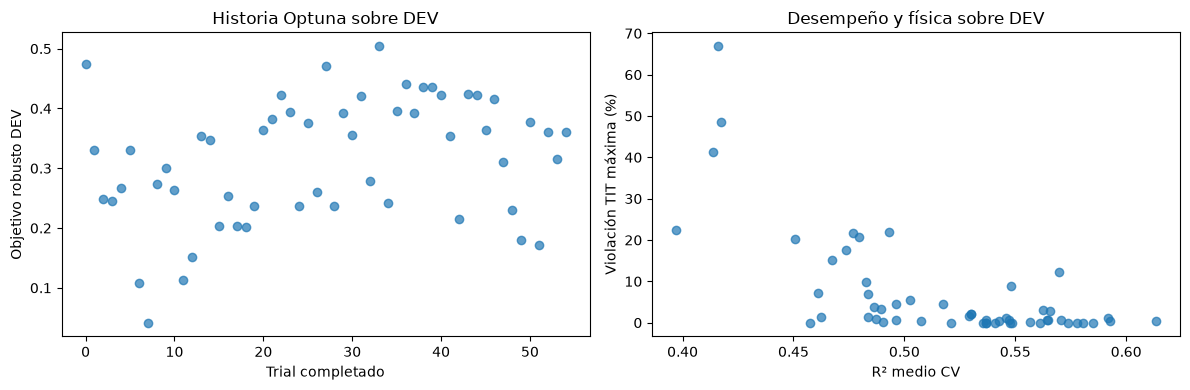

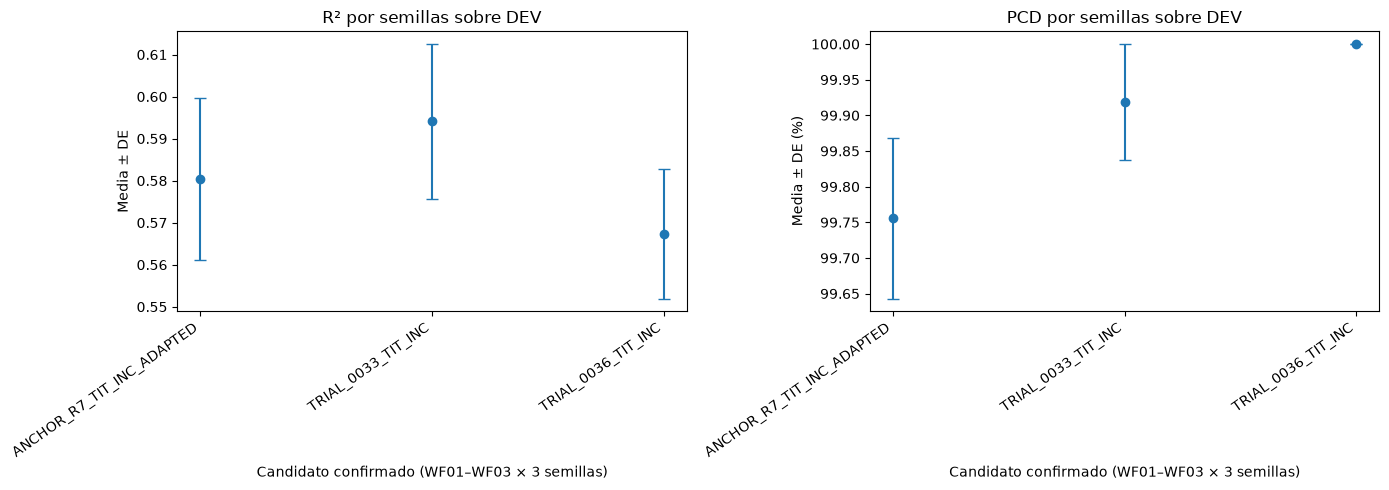

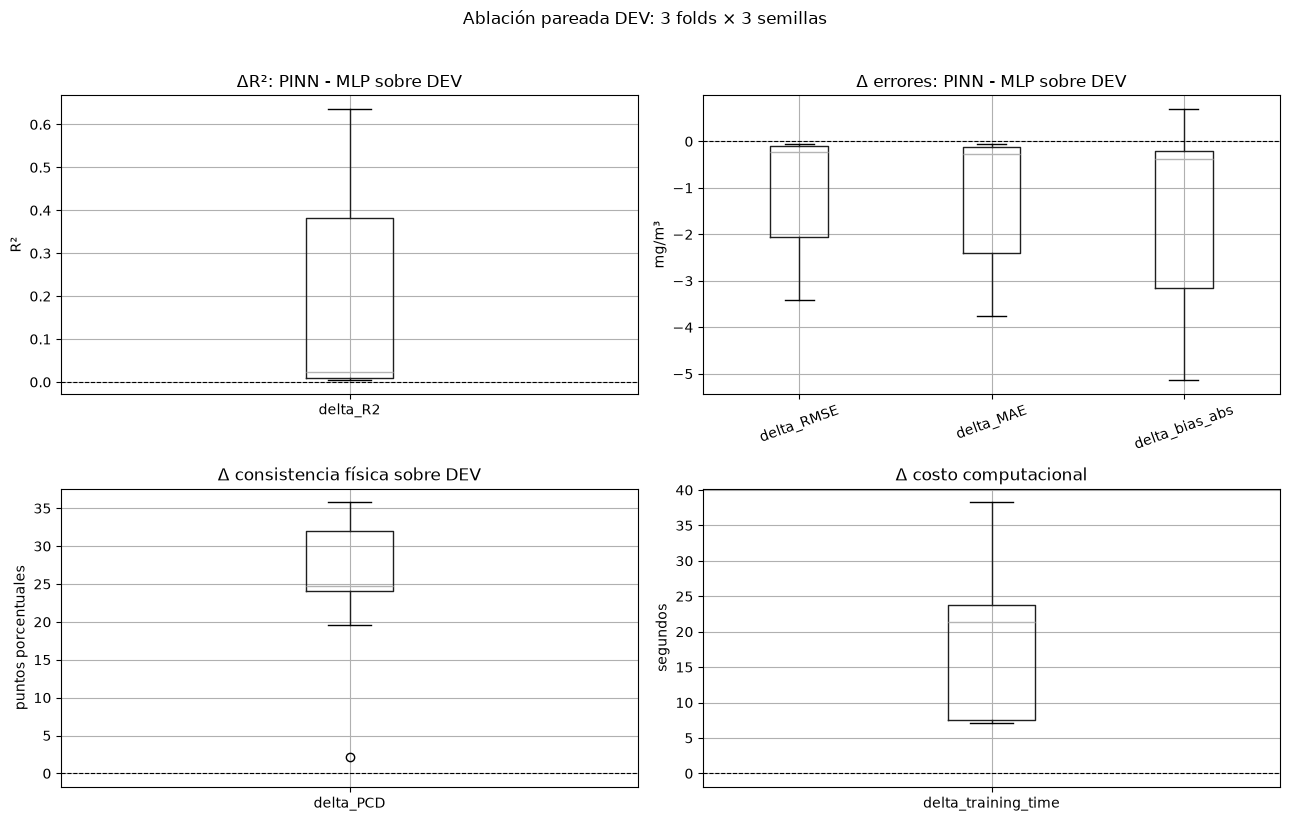

,resultado
version,NOX_WF_OPT_R3_POC_EFFICIENT
status,COMPLETE
run_mode,FULL_AUTO
updated_at,2026-08-18T22:46:51.202695+00:00
protocol_status,FROZEN
upstream_notebook,00_PEMS_PINN_WF_PROTOCOL - R1.ipynb
upstream_protocol_rel,models\wf\work_pinn_wf_protocol
authorized_direct_consumer,04_Gold_Standard_PINN_NOX_WF_FINAL - R3F_STD.i...
output_rel,models\wf\work_pinn_nox_wf_opt_r3_poc_efficient
lineage_contract_sha256,e770d3db09349ad5aa4192ded74a24cf0508a1f8a4a036...


In [56]:
# [C-12.01] Run all y resumen final
RUN_STARTED = time.perf_counter()
if RUN_MODE == "SMOKE":
    print("Fase 2 · Prueba breve de entrenamiento y persistencia")
    RESULT = run_smoke()
else:
    print("Fase 2 · Optimización Optuna sobre DEV")
    STUDY, RANKING, TRIAL_COUNTS, STOP_REASON, EVIDENCE_GATES = run_development()
    print("Fase 3 · Confirmación multisemilla, ablación y política de épocas")
    RESULT = confirmation_and_freeze(STUDY, RANKING)
    RESULT["trial_counts"] = TRIAL_COUNTS
    RESULT["stop_reason"] = STOP_REASON
    RESULT["evidence_gates"] = EVIDENCE_GATES
    plot_campaign(STUDY, RANKING, RESULT)

RUN_ELAPSED_SECONDS = time.perf_counter() - RUN_STARTED
STATE = persist_campaign_summary(RESULT, RUN_ELAPSED_SECONDS)
display(pd.Series(STATE, name="resultado").to_frame())


## OUT-06 — Cierre y registro de cambios → R3

R3 adapta la campaña focalizada del escenario interpolativo al diseño prospectivo:

- conserva `WF_PROTOCOL_R1` sin reescribir su política histórica de campaña;
- fija `TIT_INC` y el espacio simplificado;
- evalúa siempre WF01–WF03 y paraleliza folds solo tras preflight;
- cuenta únicamente trials terminales;
- confirma Top‑3, amplía Top‑2 y deriva `FINAL_EPOCHS` de 15 observaciones;
- empareja la ablación MLP con las épocas del PINN para cada semilla/fold;
- usa rutas relativas en el manifiesto y persiste `stop_reason` explícito;
- mantiene 2015 sin abrir ni hashear durante OPT.
